# E-commerce Order-Line Analytics — Exploratory Data Analysis

## Revenue drivers, returns, delivery performance, and customer segmentation

This notebook is the EDA module of an end-to-end e-commerce order-line analytics project.

This project uses a **privacy-safe e-commerce order-line dataset** designed to reflect realistic business patterns such as returns, seasonality, customer behavior, product variety, and channel performance.

This notebook focuses on exploratory analysis and business context. Predictive modeling is handled in later modules, using the revenue, return, customer, product, channel, and fulfillment signals identified here.

The main questions are:

- Which product families and channels drive realized revenue?
- Where are returns concentrated?
- How does seasonality affect revenue and return behavior?
- What do quantity, pricing, and delivery timing reveal about customer behavior?
- Are customer segments commercially healthy, or do returns change the view?


# 1. Dataset Overview

## Dataset granularity

The dataset is structured at the **order-line level**. Each row represents one item line within a transaction.

Key identifiers:

- `transaction_id`: transaction/order identifier
- `transaction_line_id`: unique order-line identifier
- `item_key`: product/item identifier
- `customer_key`: customer identifier

One transaction can contain multiple order lines, which makes this granularity useful for product-level revenue analysis, return behavior, quantity effects, and customer segmentation.

## Time coverage

The order data covers **2024-01-01 to 2024-12-31**. Dispatch, delivery, and return timestamps may extend beyond the order date when the operational event occurs later.

## Core business definitions

- **`net_revenue`**: purchase-time line revenue before return impact
- **`realized_revenue`**: line revenue retained after return impact
- **`was_returned`**: return indicator for the order line

`realized_revenue` is the main commercial measure used throughout the notebook because it reflects the revenue retained after returns.

## Main EDA questions

| Area | Business question |
|---|---|
| Revenue | Which categories, channels, and time periods generate the most realized revenue? |
| Returns | Where is return risk concentrated, and how does it affect retained revenue? |
| Product mix | Which product families combine scale, revenue, and acceptable return behavior? |
| Marketing channels | Which channels bring volume and revenue quality, not only traffic? |
| Operations | How are delivery delays and fulfillment patterns related to return behavior? |
| Customers | Are high-value customers concentrated, healthy, or exposed to return risk? |

# 2. Data Loading and Validation

This section loads the dataset, checks the expected structure, and runs a first round of validation before analysis.

The checks focus on practical data quality questions:

- Are the expected identifiers and business fields available?
- Is the order-line key unique?
- Are critical fields complete?
- Are missing values limited to acceptable non-critical fields?
- Are revenue, return, and date fields logically consistent?


In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Visualization style
sns.set_theme(style="whitegrid", context="notebook")


## 2.1 Load schema mapping

The schema mapping defines the shared column names used across notebooks. A fallback schema is included so the notebook remains reproducible even when the config file is not available locally.


In [2]:
def load_schema_mapping():
    """Load public schema mapping from config file, with a safe fallback."""
    candidate_paths = [
        Path("config/schema_mapping.json"),
        Path("../config/schema_mapping.json"),
            ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading schema mapping from: {path}")
            return json.loads(path.read_text())

    print("Schema mapping file not found. Using built-in schema fallback.")

    return {
        "order_id": "transaction_id",
        "order_line_id": "transaction_line_id",
        "customer_id": "customer_key",
        "item_id": "item_key",
        "session_id": "session_key",
        "order_date": "order_timestamp",
        "dispatch_date": "dispatch_timestamp",
        "delivery_date": "delivery_timestamp",
        "return_date": "return_timestamp",
        "original_revenue": "net_revenue",
        "realized_revenue": "realized_revenue",
        "return_flag": "was_returned",
        "quantity": "quantity",
        "product_category": "product_family",
        "product_subcategory": "product_group",
        "channel": "acquisition_channel",
        "campaign": "campaign_group",
        "traffic_source": "traffic_source_group",
        "carrier": "fulfillment_partner",
        "shipping_delay": "delivery_delay_days",
        "dispatch_delay": "dispatch_delay_days",
        "price": "sale_price",
        "list_price": "list_price",
        "discount": "discount_amount",
        "tax_rate": "tax_rate",
        "tax_amount": "tax_amount",
        "customer_region": "customer_region",
        "loyalty_tier": "loyalty_tier",
    }


SCHEMA = load_schema_mapping()
SCHEMA


Loading schema mapping from: ../config/schema_mapping.json


{'order_id': 'transaction_id',
 'order_line_id': 'transaction_line_id',
 'customer_id': 'customer_key',
 'item_id': 'item_key',
 'session_id': 'session_key',
 'order_date': 'order_timestamp',
 'dispatch_date': 'dispatch_timestamp',
 'delivery_date': 'delivery_timestamp',
 'return_date': 'return_timestamp',
 'original_revenue': 'net_revenue',
 'realized_revenue': 'realized_revenue',
 'return_flag': 'was_returned',
 'quantity': 'quantity',
 'product_category': 'product_family',
 'product_subcategory': 'product_group',
 'channel': 'acquisition_channel',
 'campaign': 'campaign_group',
 'traffic_source': 'traffic_source_group',
 'carrier': 'fulfillment_partner',
 'shipping_delay': 'delivery_delay_days',
 'dispatch_delay': 'dispatch_delay_days',
 'price': 'sale_price',
 'list_price': 'list_price',
 'discount': 'discount_amount',
 'tax_rate': 'tax_rate',
 'tax_amount': 'tax_amount',
 'customer_region': 'customer_region',
 'loyalty_tier': 'loyalty_tier'}

## 2.2 Load the dataset

The notebook supports both a full Parquet file and a compressed CSV sample. This keeps local review lightweight while still allowing larger runs when the full dataset is available.


In [3]:
def load_public_synthetic_dataset():
    """Load public synthetic dataset from Parquet or compressed CSV fallback."""
    candidate_paths = [
        Path("data/synthetic_orderline_2024.parquet"),
        Path("data/synthetic_orderline_2024.csv.gz"),
        Path("data/synthetic_orderline_2024_sample.csv.gz"),
        Path("../data/synthetic_orderline_2024.parquet"),
        Path("../data/synthetic_orderline_2024.csv.gz"),
        Path("../data/synthetic_orderline_2024_sample.csv.gz"),
            ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading dataset from: {path}")

            if path.suffix == ".parquet":
                return pd.read_parquet(path)

            return pd.read_csv(
                path,
                low_memory=False,
                parse_dates=[
                    SCHEMA["order_date"],
                    SCHEMA["dispatch_date"],
                    SCHEMA["delivery_date"],
                    SCHEMA["return_date"],
                ]
            )

    raise FileNotFoundError(
        "Public synthetic dataset not found. Expected one of: "
        "data/synthetic_orderline_2024.parquet, "
        "data/synthetic_orderline_2024.csv.gz, or "
        "data/synthetic_orderline_2024_sample.csv.gz"
    )


df_raw = load_public_synthetic_dataset()

print("Raw dataset shape:", df_raw.shape)


Loading dataset from: ../data/synthetic_orderline_2024.parquet
Raw dataset shape: (4262864, 42)


## 2.3 Data preview

The preview checks that the data contains transaction, product, customer, revenue, return, channel, and fulfillment fields at order-line level.


In [4]:
df_raw.head()


,transaction_id,transaction_line_id,line_number,customer_key,item_key,session_key,order_timestamp,dispatch_timestamp,delivery_timestamp,return_timestamp,product_family,product_group,item_variant,size_code_public,color_group,assortment_type,customer_segment_seed,customer_region,loyalty_tier,customer_join_month,list_price,sale_price,net_revenue,realized_revenue,discount_amount,quantity,tax_rate,tax_amount,was_returned,return_reason_group,returned_quantity,returned_revenue,fulfillment_partner,delivery_mode,dispatch_delay_days,delivery_delay_days,acquisition_channel,campaign_group,traffic_source_group,order_year,order_month,order_weekday
0,TXN-2024-000000001,LINE-2024-0000000001,1,CUST-00245651,ITEM-0027199,SESS-2024-0000000001,2024-11-14 20:00:53,2024-11-15 20:00:53,2024-11-19 20:00:53,NaT,Office & Study,Organization,value,OneSize,neutral,core_range,high_return,Westport,gold,2024-07,14.400,11.770,23.540,23.540,5.260,2,0.000,0.000,0,not_returned,0,0.000,BoxBridge,standard,1,4,direct_web,always_on,search_engine,2024,11,Thursday
1,TXN-2024-000000001,LINE-2024-0000000002,2,CUST-00245651,ITEM-0057254,SESS-2024-0000000001,2024-11-14 20:00:53,2024-11-15 20:00:53,2024-11-19 20:00:53,NaT,Kids Essentials,Sleep,core,L,mixed,seasonal_range,high_return,Central Plains,gold,2024-09,31.710,31.710,31.710,31.710,0.000,1,0.190,6.020,0,not_returned,0,0.000,BoxBridge,standard,1,4,direct_web,always_on,comparison_site,2024,11,Thursday
2,TXN-2024-000000002,LINE-2024-0000000003,1,CUST-00452029,ITEM-0163028,SESS-2024-0000000002,2024-01-22 18:10:43,2024-01-23 18:10:43,2024-01-25 18:10:43,NaT,Digital Accessories,Cables,limited,OneSize,green,core_range,premium,Highland,platinum,2024-01,18.760,16.600,16.600,16.600,2.170,1,0.190,3.150,0,not_returned,0,0.000,UrbanRoute,express,1,2,organic_search,always_on,type_in,2024,1,Monday
3,TXN-2024-000000003,LINE-2024-0000000004,1,CUST-00014089,ITEM-0089146,SESS-2024-0000000003,2024-05-10 20:43:50,2024-05-12 20:43:50,2024-05-13 20:43:50,NaT,Everyday Apparel,Basics,core,L,not_applicable,core_range,premium,Metro Core,gold,2023-07,32.280,26.950,26.950,26.950,5.330,1,0.190,5.120,0,not_returned,0,0.000,EcoShip,express,2,1,email_campaign,always_on,social_feed,2024,5,Friday
4,TXN-2024-000000003,LINE-2024-0000000005,2,CUST-00014089,ITEM-0001754,SESS-2024-0000000003,2024-05-10 20:43:50,2024-05-12 20:43:50,2024-05-13 20:43:50,NaT,Beauty & Care,Wellness,premium,L,not_applicable,core_range,premium,Westport,gold,2022-11,15.700,15.700,15.700,15.700,0.000,1,0.210,3.300,0,not_returned,0,0.000,EcoShip,express,2,1,email_campaign,always_on,partner_site,2024,5,Friday


## 2.4 Structure and data types

The data type review confirms whether timestamps, numeric revenue fields, quantities, and categorical business attributes are loaded in the expected formats.

In [5]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 4262864 entries, 0 to 4262863
Data columns (total 42 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         str           
 1   transaction_line_id    str           
 2   line_number            int64         
 3   customer_key           str           
 4   item_key               str           
 5   session_key            str           
 6   order_timestamp        datetime64[us]
 7   dispatch_timestamp     datetime64[us]
 8   delivery_timestamp     datetime64[us]
 9   return_timestamp       datetime64[us]
 10  product_family         str           
 11  product_group          str           
 12  item_variant           str           
 13  size_code_public       str           
 14  color_group            str           
 15  assortment_type        str           
 16  customer_segment_seed  str           
 17  customer_region        str           
 18  loyalty_tier           str       

## 2.5 Column inventory

This column inventory provides a quick audit of the fields available for analysis.


In [6]:
sorted(df_raw.columns.tolist())


['acquisition_channel',
 'assortment_type',
 'campaign_group',
 'color_group',
 'customer_join_month',
 'customer_key',
 'customer_region',
 'customer_segment_seed',
 'delivery_delay_days',
 'delivery_mode',
 'delivery_timestamp',
 'discount_amount',
 'dispatch_delay_days',
 'dispatch_timestamp',
 'fulfillment_partner',
 'item_key',
 'item_variant',
 'line_number',
 'list_price',
 'loyalty_tier',
 'net_revenue',
 'order_month',
 'order_timestamp',
 'order_weekday',
 'order_year',
 'product_family',
 'product_group',
 'quantity',
 'realized_revenue',
 'return_reason_group',
 'return_timestamp',
 'returned_quantity',
 'returned_revenue',
 'sale_price',
 'session_key',
 'size_code_public',
 'tax_amount',
 'tax_rate',
 'traffic_source_group',
 'transaction_id',
 'transaction_line_id',
 'was_returned']

## 2.6 Descriptive profile

The descriptive summary gives an initial view of numeric ranges, categorical cardinality, and fields that may need closer inspection.


In [7]:
df_raw.describe(include="all").transpose().head(30)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,4262864,2254806,TXN-2024-000000051,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_line_id,4262864,4262864,LINE-2024-0000000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
line_number,"4,262,864.000",NaN,NaN,NaN,1.831,1.000,1.000,1.000,2.000,6.000,1.124
customer_key,4262864,430113,CUST-00440059,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_key,4262864,193762,ITEM-0029394,15838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_key,4262864,2254806,SESS-2024-0000000051,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_timestamp,4262864,NaN,NaN,NaN,2024-07-22 09:14:54.238077,2024-01-01 00:00:27,2024-04-21 17:31:16,2024-08-01 18:57:27,2024-10-29 16:09:46,2024-12-31 23:59:32,NaN
dispatch_timestamp,4262864,NaN,NaN,NaN,2024-07-23 11:37:48.662782,2024-01-01 00:00:42,2024-04-22 19:10:48,2024-08-02 19:52:03,2024-10-30 17:45:04,2025-01-07 18:29:00,NaN
delivery_timestamp,4262864,NaN,NaN,NaN,2024-07-27 15:30:01.781176,2024-01-02 00:19:37,2024-04-26 22:12:17,2024-08-06 23:16:56,2024-11-03 19:35:49,2025-01-13 18:07:13,NaN
return_timestamp,470625,NaN,NaN,NaN,2024-08-21 23:26:46.034589,2024-01-06 09:00:21,2024-05-23 01:06:21,2024-09-09 08:17:40,2024-11-29 16:43:41,2025-02-09 20:40:40,NaN


## 2.7 Duplicate row check

Duplicate rows can distort revenue, return rates, and customer metrics. This check to confirm that the dataset does not contain fully duplicated records.

In [8]:
duplicate_rows = df_raw.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)


Number of duplicate rows: 0


## 2.8 Row-level key validation

Because the dataset is at order-line level, `transaction_id` alone is not expected to be unique. The unique analytical key is `transaction_line_id`.

In [9]:
order_line_col = SCHEMA["order_line_id"]
order_col = SCHEMA["order_id"]

duplicate_line_keys = df_raw.duplicated(subset=[order_line_col]).sum()
duplicate_order_line_combo = df_raw.duplicated(subset=[order_col, order_line_col]).sum()

print("Duplicate transaction_line_id rows:", duplicate_line_keys)
print("Duplicate transaction_id + transaction_line_id rows:", duplicate_order_line_combo)


Duplicate transaction_line_id rows: 0
Duplicate transaction_id + transaction_line_id rows: 0


**Interpretation:** `transaction_line_id` is unique, so each row can be treated as one distinct analytical unit. This avoids double-counting revenue, quantities, and returns in later groupby analyses.


## 2.9 Missing-value overview

Some missing data is expected (like no return date for non-returned items), while other missing data may signal problems in the dataset.

In [10]:
missing_summary = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_pct"] = 100 * missing_summary["missing_count"] / len(df_raw)
missing_summary.head(20)


,missing_count,missing_pct
return_timestamp,3792239,88.960
traffic_source_group,63634,1.493
campaign_group,42486,0.997
fulfillment_partner,21190,0.497
customer_region,17224,0.404
returned_quantity,0,0.000
discount_amount,0,0.000
quantity,0,0.000
tax_rate,0,0.000
tax_amount,0,0.000


**Interpretation:** The largest missing field is `return_timestamp`, which is expected because most order lines are not returned. Low missingness in fields such as traffic source, campaign group, fulfillment partner, and region can be handled as `Unknown` for aggregate analysis without affecting the core revenue and return metrics.


# 3. Data Cleaning and Feature Preparation

This section prepares the dataset for analysis while preserving the business meaning of each field.

The preparation work covers:

1. Creating a stable working copy
2. Validating critical columns
3. Standardizing date fields
4. Confirming return and realized revenue logic
5. Handling non-critical missing values
6. Reviewing numeric ranges and outliers
7. Creating derived variables for EDA and later modeling


## 3.1 Create a working copy

In [11]:
df = df_raw.copy()
print("Working dataset shape:", df.shape)


Working dataset shape: (4262864, 42)


## 3.2 Validate critical fields

Critical identifiers, dates, revenue fields, quantities, and return flags must be complete because they drive the main EDA and downstream modeling tasks.

In [12]:
critical_cols = [
    SCHEMA["order_id"],
    SCHEMA["order_line_id"],
    SCHEMA["customer_id"],
    SCHEMA["item_id"],
    SCHEMA["order_date"],
    SCHEMA["original_revenue"],
    SCHEMA["realized_revenue"],
    SCHEMA["return_flag"],
    SCHEMA["quantity"],
]

critical_missing = df[critical_cols].isna().sum().sort_values(ascending=False)

display(critical_missing.to_frame("missing_count"))
print("Total missing critical cells:", critical_missing.sum())


,missing_count
transaction_id,0
transaction_line_id,0
customer_key,0
item_key,0
order_timestamp,0
net_revenue,0
realized_revenue,0
was_returned,0
quantity,0


Total missing critical cells: 0


**Interpretation:** Critical fields have no missing values. Revenue, return, customer, product, and transaction identifiers can therefore be used safely as the basis for the main analysis and modeling modules.


## 3.3 Convert date columns

Consistent datetime fields are required for seasonality analysis, delivery-delay analysis, customer recency, and future forecasting modules.

In [13]:
date_columns = [
    SCHEMA["order_date"],
    SCHEMA["dispatch_date"],
    SCHEMA["delivery_date"],
    SCHEMA["return_date"],
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_columns].dtypes


order_timestamp       datetime64[us]
dispatch_timestamp    datetime64[us]
delivery_timestamp    datetime64[us]
return_timestamp      datetime64[us]
dtype: object

## 3.4 Define return target and realized revenue

The dataset includes the return flag and both purchase-time and return-adjusted revenue measures. `realized_revenue` is used as the main retained-revenue measure because it captures the commercial impact of returns, including partially returned multi-quantity lines.


In [14]:
return_col = SCHEMA["return_flag"]
net_revenue_col = SCHEMA["original_revenue"]
realized_revenue_col = SCHEMA["realized_revenue"]

df[return_col] = pd.to_numeric(df[return_col], errors="coerce").fillna(0).astype(int)

if realized_revenue_col not in df.columns:
    df[realized_revenue_col] = np.where(df[return_col] == 1, 0, df[net_revenue_col])

return_rate = df[return_col].mean()

print(f"Overall return rate: {return_rate:.2%}")
df[[net_revenue_col, realized_revenue_col, return_col]].head()


Overall return rate: 11.04%


,net_revenue,realized_revenue,was_returned
0,23.540,23.540,0
1,31.710,31.710,0
2,16.600,16.600,0
3,26.950,26.950,0
4,15.700,15.700,0


**Interpretation:** The overall return rate is **11.04%**. That is high enough to affect retained revenue, so return behavior deserves direct analysis rather than being treated as a minor operational detail.


## 3.5 Review missing values

Low missingness in selected non-critical business fields is acceptable and reflects realistic operational data. Event timestamps remain missing when the event did not occur.

In [15]:
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_pct"] = 100 * missing_summary["missing_count"] / len(df)
missing_summary.head(20)


,missing_count,missing_pct
return_timestamp,3792239,88.960
traffic_source_group,63634,1.493
campaign_group,42486,0.997
fulfillment_partner,21190,0.497
customer_region,17224,0.404
returned_quantity,0,0.000
discount_amount,0,0.000
quantity,0,0.000
tax_rate,0,0.000
tax_amount,0,0.000


### Missing-value handling strategy

For this EDA notebook:

- Critical analytical fields are expected to be complete.
- Selected categorical fields are filled with `Unknown` to keep groupby outputs readable.
- Event timestamps remain missing when the event did not occur, such as return timestamps for non-returned lines.
- No revenue or return records are removed unless there is a clear data-quality reason.


In [16]:
categorical_fill_cols = [
    SCHEMA["product_category"],
    SCHEMA["product_subcategory"],
    SCHEMA["channel"],
    SCHEMA["campaign"],
    SCHEMA["traffic_source"],
    SCHEMA["carrier"],
    "delivery_mode",
    SCHEMA["customer_region"],
    SCHEMA["loyalty_tier"],
]

for col in categorical_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")


## 3.6 Review key numeric fields

This review checks whether prices, revenue, discounts, quantities, tax fields, and delay fields have plausible ranges before visual analysis.

In [17]:
numeric_review_cols = [
    SCHEMA["list_price"],
    SCHEMA["price"],
    SCHEMA["original_revenue"],
    SCHEMA["realized_revenue"],
    SCHEMA["discount"],
    SCHEMA["quantity"],
    SCHEMA["tax_rate"],
    SCHEMA["tax_amount"],
    SCHEMA["dispatch_delay"],
    SCHEMA["shipping_delay"],
]

available_numeric_review_cols = [c for c in numeric_review_cols if c in df.columns]
df[available_numeric_review_cols].describe().transpose()


,count,mean,std,min,25%,50%,75%,max
list_price,"4,262,864.000",32.657,22.101,2.160,17.680,26.770,40.950,515.990
sale_price,"4,262,864.000",25.658,18.554,1.260,13.240,20.600,32.310,437.430
net_revenue,"4,262,864.000",36.831,34.766,1.260,16.310,26.800,44.940,"1,669.130"
realized_revenue,"4,262,864.000",33.486,34.418,0.000,13.720,24.440,42.160,"1,669.130"
discount_amount,"4,262,864.000",10.113,13.268,0.000,1.450,6.650,13.410,549.560
quantity,"4,262,864.000",1.511,0.972,1.000,1.000,1.000,2.000,6.000
tax_rate,"4,262,864.000",0.153,0.065,0.000,0.070,0.190,0.190,0.210
tax_amount,"4,262,864.000",5.621,6.250,0.000,1.950,3.840,7.080,317.140
dispatch_delay_days,"4,262,864.000",1.099,1.049,0.000,0.000,1.000,2.000,8.000
delivery_delay_days,"4,262,864.000",4.161,1.528,1.000,3.000,4.000,5.000,13.000


**Interpretation:** The numeric profile shows plausible ranges for prices, revenue, quantities, discounts, and delay variables. Revenue fields are skewed, which is common in transactional e-commerce data and should be considered in later models.


## 3.7 Visual outlier review

High-value order lines may be valid business events. The goal here is to inspect skew and extreme values, not to remove observations automatically.

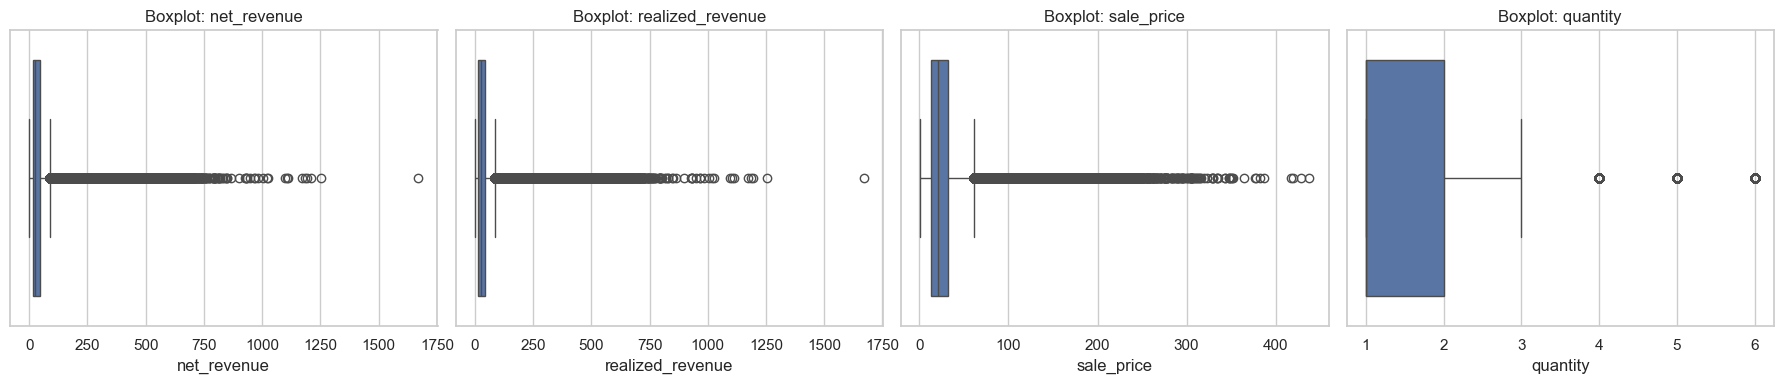

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

boxplot_cols = [
    SCHEMA["original_revenue"],
    SCHEMA["realized_revenue"],
    SCHEMA["price"],
    SCHEMA["quantity"],
]

for ax, col in zip(axes, boxplot_cols):
    if col in df.columns:
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()


**Interpretation:** The boxplots show long-tailed revenue and price behavior. These high-value lines should not be removed automatically; they may represent valid commercial activity and can be important for revenue modeling and customer value analysis.


## 3.8 Create derived variables

Derived variables make the analysis easier to read and create reusable features for later modules. These include calendar features, unit-price logic, log revenue, and return-adjusted fields.


In [19]:
order_date_col = SCHEMA["order_date"]
dispatch_date_col = SCHEMA["dispatch_date"]
delivery_date_col = SCHEMA["delivery_date"]
quantity_col = SCHEMA["quantity"]
price_col = SCHEMA["price"]

# Time features
df["order_year"] = df[order_date_col].dt.year
df["order_month"] = df[order_date_col].dt.month
df["order_weekday"] = df[order_date_col].dt.day_name()
df["order_month_period"] = df[order_date_col].dt.to_period("M").astype(str)

# Pricing features
df["price_per_item"] = np.where(
    df[quantity_col].fillna(0) > 0,
    df[price_col] / df[quantity_col],
    np.nan
)

# Shipping performance
if dispatch_date_col in df.columns:
    df["dispatch_delay_calculated_days"] = (df[dispatch_date_col] - df[order_date_col]).dt.days

if delivery_date_col in df.columns and dispatch_date_col in df.columns:
    df["delivery_delay_calculated_days"] = (df[delivery_date_col] - df[dispatch_date_col]).dt.days

# Revenue helpers
df["log_net_revenue"] = np.log1p(df[net_revenue_col].clip(lower=0))
df["log_realized_revenue"] = np.log1p(df[realized_revenue_col].clip(lower=0))

# Quantity helper
df["is_multi_qty_line"] = (df[quantity_col].fillna(0) > 1).astype(int)


## 3.9 Build the master analysis dataset

The master analysis dataset keeps the fields needed for EDA, product analysis, channel analysis, delivery analysis, customer segmentation, and downstream ML modules.

Some fields useful for EDA may later be excluded from predictive models to avoid leakage.


In [20]:
analysis_columns = [
    # Keys / structure
    SCHEMA["order_id"], SCHEMA["order_line_id"], SCHEMA["item_id"], SCHEMA["customer_id"], SCHEMA["session_id"],

    # Time
    SCHEMA["order_date"], SCHEMA["dispatch_date"], SCHEMA["delivery_date"], SCHEMA["return_date"],

    # Product
    SCHEMA["product_category"], SCHEMA["product_subcategory"], "item_variant",
    "size_code_public", "color_group", "assortment_type",

    # Customer
    "customer_segment_seed", SCHEMA["customer_region"], SCHEMA["loyalty_tier"], "customer_join_month",

    # Pricing / revenue
    SCHEMA["list_price"], SCHEMA["price"], SCHEMA["original_revenue"], SCHEMA["realized_revenue"],
    SCHEMA["discount"], SCHEMA["quantity"], SCHEMA["tax_rate"], SCHEMA["tax_amount"],

    # Returns
    SCHEMA["return_flag"], "return_reason_group", "returned_quantity", "returned_revenue",

    # Delivery / fulfillment
    SCHEMA["carrier"], "delivery_mode", SCHEMA["dispatch_delay"], SCHEMA["shipping_delay"],
    "dispatch_delay_calculated_days", "delivery_delay_calculated_days",

    # Marketing / acquisition
    SCHEMA["channel"], SCHEMA["campaign"], SCHEMA["traffic_source"],

    # Derived variables
    "order_year", "order_month", "order_weekday", "order_month_period",
    "price_per_item", "log_net_revenue", "log_realized_revenue", "is_multi_qty_line",
]

analysis_columns = [c for c in analysis_columns if c in df.columns]
analysis_df = df[analysis_columns].copy()

print("Master Analysis Dataset shape:", analysis_df.shape)
analysis_df.head()


Master Analysis Dataset shape: (4262864, 48)


,transaction_id,transaction_line_id,item_key,customer_key,session_key,order_timestamp,dispatch_timestamp,delivery_timestamp,return_timestamp,product_family,product_group,item_variant,size_code_public,color_group,assortment_type,customer_segment_seed,customer_region,loyalty_tier,customer_join_month,list_price,sale_price,net_revenue,realized_revenue,discount_amount,quantity,tax_rate,tax_amount,was_returned,return_reason_group,returned_quantity,returned_revenue,fulfillment_partner,delivery_mode,dispatch_delay_days,delivery_delay_days,dispatch_delay_calculated_days,delivery_delay_calculated_days,acquisition_channel,campaign_group,traffic_source_group,order_year,order_month,order_weekday,order_month_period,price_per_item,log_net_revenue,log_realized_revenue,is_multi_qty_line
0,TXN-2024-000000001,LINE-2024-0000000001,ITEM-0027199,CUST-00245651,SESS-2024-0000000001,2024-11-14 20:00:53,2024-11-15 20:00:53,2024-11-19 20:00:53,NaT,Office & Study,Organization,value,OneSize,neutral,core_range,high_return,Westport,gold,2024-07,14.400,11.770,23.540,23.540,5.260,2,0.000,0.000,0,not_returned,0,0.000,BoxBridge,standard,1,4,1,4,direct_web,always_on,search_engine,2024,11,Thursday,2024-11,5.885,3.200,3.200,1
1,TXN-2024-000000001,LINE-2024-0000000002,ITEM-0057254,CUST-00245651,SESS-2024-0000000001,2024-11-14 20:00:53,2024-11-15 20:00:53,2024-11-19 20:00:53,NaT,Kids Essentials,Sleep,core,L,mixed,seasonal_range,high_return,Central Plains,gold,2024-09,31.710,31.710,31.710,31.710,0.000,1,0.190,6.020,0,not_returned,0,0.000,BoxBridge,standard,1,4,1,4,direct_web,always_on,comparison_site,2024,11,Thursday,2024-11,31.710,3.488,3.488,0
2,TXN-2024-000000002,LINE-2024-0000000003,ITEM-0163028,CUST-00452029,SESS-2024-0000000002,2024-01-22 18:10:43,2024-01-23 18:10:43,2024-01-25 18:10:43,NaT,Digital Accessories,Cables,limited,OneSize,green,core_range,premium,Highland,platinum,2024-01,18.760,16.600,16.600,16.600,2.170,1,0.190,3.150,0,not_returned,0,0.000,UrbanRoute,express,1,2,1,2,organic_search,always_on,type_in,2024,1,Monday,2024-01,16.600,2.868,2.868,0
3,TXN-2024-000000003,LINE-2024-0000000004,ITEM-0089146,CUST-00014089,SESS-2024-0000000003,2024-05-10 20:43:50,2024-05-12 20:43:50,2024-05-13 20:43:50,NaT,Everyday Apparel,Basics,core,L,not_applicable,core_range,premium,Metro Core,gold,2023-07,32.280,26.950,26.950,26.950,5.330,1,0.190,5.120,0,not_returned,0,0.000,EcoShip,express,2,1,2,1,email_campaign,always_on,social_feed,2024,5,Friday,2024-05,26.950,3.330,3.330,0
4,TXN-2024-000000003,LINE-2024-0000000005,ITEM-0001754,CUST-00014089,SESS-2024-0000000003,2024-05-10 20:43:50,2024-05-12 20:43:50,2024-05-13 20:43:50,NaT,Beauty & Care,Wellness,premium,L,not_applicable,core_range,premium,Westport,gold,2022-11,15.700,15.700,15.700,15.700,0.000,1,0.210,3.300,0,not_returned,0,0.000,EcoShip,express,2,1,2,1,email_campaign,always_on,partner_site,2024,5,Friday,2024-05,15.700,2.815,2.815,0


**Interpretation:** The master analysis dataset contains **4,262,864 rows** and **48 columns** after derived variables are added. This creates a reusable analytical layer for EDA and the downstream modeling notebooks.


## 3.10 Data preparation summary

The dataset is now analysis-ready:

- Critical fields are complete.
- The order-line key is unique.
- Date fields are standardized.
- Return-aware revenue is available.
- Non-critical missing categorical values are handled consistently.
- Derived features are available for revenue, return, time, price, and customer analysis.


# 4. Exploratory Data Analysis

Main analysis areas:

1. Revenue distribution
2. Return behavior
3. Product family performance
4. Monthly trends and seasonality
5. Quantity behavior
6. Acquisition channel and campaign analysis
7. Price and return relationship
8. Delivery and fulfillment performance
9. RFM-R customer segmentation


## 4.1 Revenue distribution

**Business question:** How is revenue distributed at order-line level, and how much revenue is retained after returns?

Revenue is analyzed from two perspectives:

- `net_revenue`: purchase-time revenue
- `realized_revenue`: revenue retained after returns

This distinction is important because high sales volume can overstate business performance when return behavior is material.

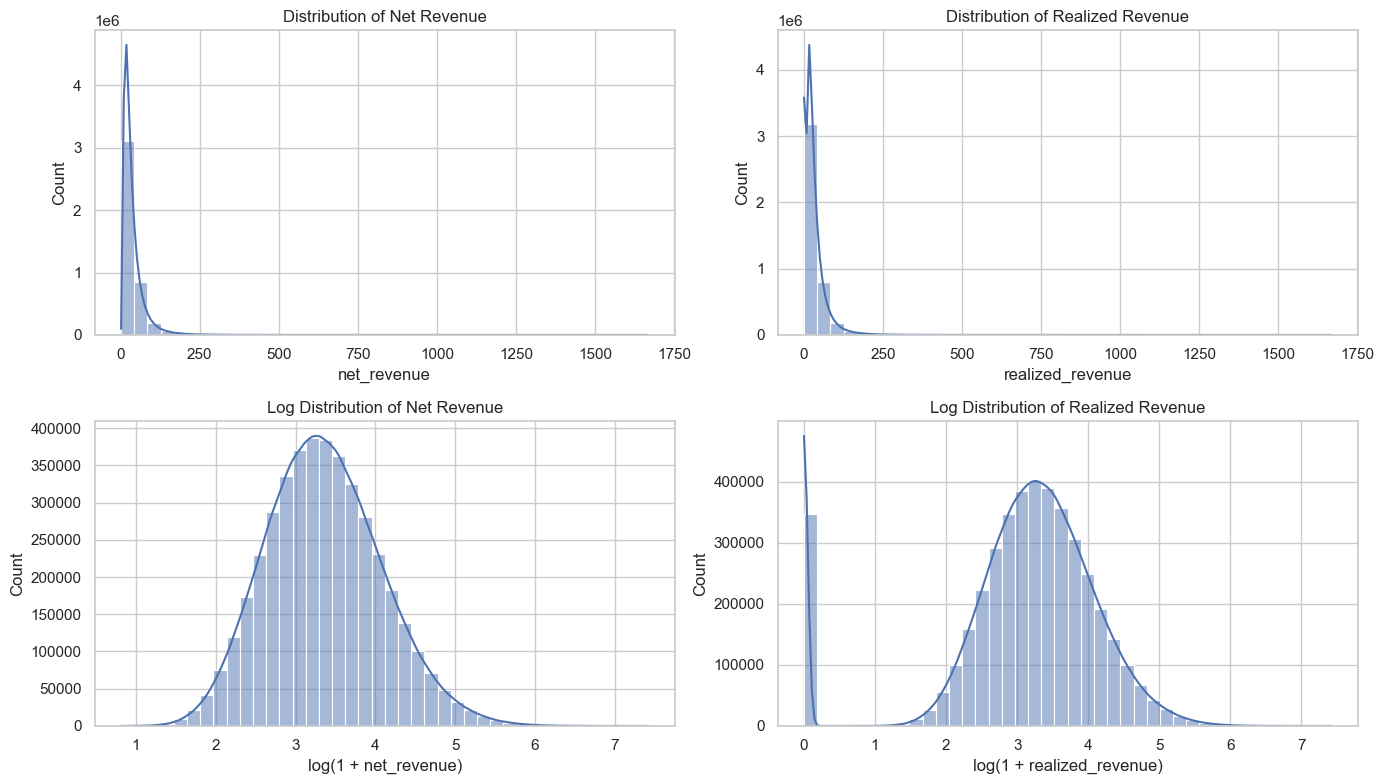

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(analysis_df[net_revenue_col], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Net Revenue")
axes[0, 0].set_xlabel("net_revenue")

sns.histplot(analysis_df[realized_revenue_col], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Realized Revenue")
axes[0, 1].set_xlabel("realized_revenue")

sns.histplot(analysis_df["log_net_revenue"], bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Log Distribution of Net Revenue")
axes[1, 0].set_xlabel("log(1 + net_revenue)")

sns.histplot(analysis_df["log_realized_revenue"], bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Log Distribution of Realized Revenue")
axes[1, 1].set_xlabel("log(1 + realized_revenue)")

plt.tight_layout()
plt.show()


In [22]:
pd.concat(
    [
        analysis_df[net_revenue_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).rename("net_revenue"),
        analysis_df[realized_revenue_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).rename("realized_revenue")
    ],
    axis=1
)


,net_revenue,realized_revenue
count,"4,262,864.000","4,262,864.000"
mean,36.831,33.486
std,34.766,34.418
min,1.260,0.000
25%,16.310,13.720
50%,26.800,24.440
75%,44.940,42.160
90%,72.820,69.270
95%,98.110,93.850
99%,174.820,168.250


### Revenue interpretation

The histograms show a strongly right-skewed revenue pattern: many relatively small lines and a smaller number of much larger lines. The log-revenue view makes this pattern easier to inspect and is a useful signal for later modeling.

Average realized revenue is lower than average net revenue, which confirms that returns have a visible impact on retained revenue.

Most order lines sit in a lower-to-mid revenue range, while a smaller group of high-value lines creates a long tail. The median realized revenue is **24.44**, and the 99th percentile is **168.25**. This matters because average revenue alone can hide the typical customer transaction pattern. Later revenue models should account for skew, and reporting should track both typical order-line value and high-value tail behavior.


## 4.2 Return rate analysis

**Business question:** Where is return risk concentrated, and which dimensions should be monitored before modeling?

Returns are reviewed by product family and acquisition channel to identify operational and commercial segments with elevated return behavior.

In [23]:
overall_return_rate = analysis_df[return_col].mean()
print(f"Overall return rate: {overall_return_rate:.2%}")


Overall return rate: 11.04%


### 4.2.1 Product families with higher return behavior

,return_rate,order_lines
product_family,,
Everyday Apparel,0.202,735744
Active Lifestyle,0.125,429749
Kids Essentials,0.119,507687
Outdoor Living,0.116,329253
Seasonal Gifts,0.114,251182
Home Comfort,0.097,502186
Beauty & Care,0.071,424235
Digital Accessories,0.063,445676
Pet Lifestyle,0.061,262061


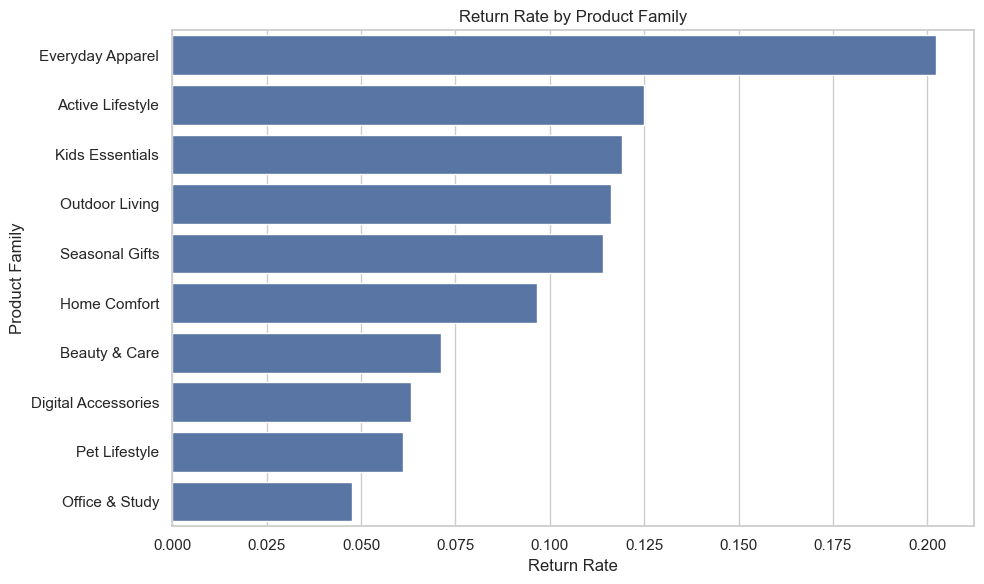

In [24]:
return_by_family = (
    analysis_df.groupby(SCHEMA["product_category"], dropna=False)[return_col]
    .agg(["mean", "count"])
    .rename(columns={"mean": "return_rate", "count": "order_lines"})
    .sort_values("return_rate", ascending=False)
)

display(return_by_family)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=return_by_family.reset_index(),
    x="return_rate",
    y=SCHEMA["product_category"]
)
plt.title("Return Rate by Product Family")
plt.xlabel("Return Rate")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()


**Everyday Apparel** has the highest return rate at **20.2%**, well above the overall return rate of **11.04%**. Active Lifestyle, Kids Essentials, Outdoor Living, and Seasonal Gifts also sit above the average. The pattern points to areas where fit, expectations, sizing, or product-description quality may matter more. These families are good candidates for better product information, sizing support, and return-risk modeling.


### 4.2.2 Channel return risk

,return_rate,order_lines
acquisition_channel,,
social_media,0.137,549281
marketplace,0.129,372510
affiliate_partner,0.121,340334
paid_search,0.117,694815
organic_search,0.107,756455
direct_web,0.094,1002758
email_campaign,0.090,546711


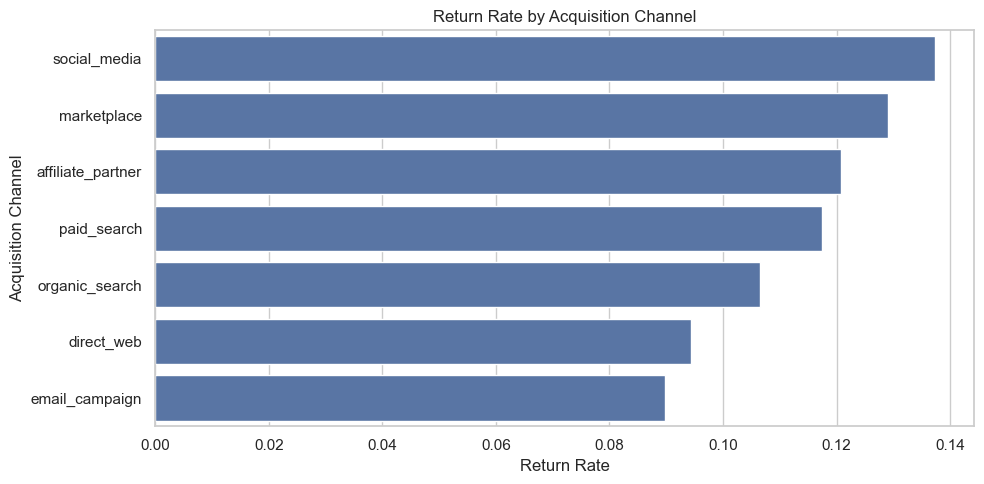

In [25]:
return_by_channel = (
    analysis_df.groupby(SCHEMA["channel"], dropna=False)[return_col]
    .agg(["mean", "count"])
    .rename(columns={"mean": "return_rate", "count": "order_lines"})
    .sort_values("return_rate", ascending=False)
)

display(return_by_channel)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=return_by_channel.reset_index(),
    x="return_rate",
    y=SCHEMA["channel"]
)
plt.title("Return Rate by Acquisition Channel")
plt.xlabel("Return Rate")
plt.ylabel("Acquisition Channel")
plt.tight_layout()
plt.show()


**Social media** has the highest channel return rate at **13.7%**, followed by **marketplace** at **12.9%** and **affiliate partner** at **12.1%**. Direct web and email campaign show lower return rates. This suggests that traffic source quality matters. High-volume channels should be judged together with retained revenue and return behavior, not only acquisition volume.


## 4.3 Product family performance

**Business question:** Which product families drive realized revenue, and which combine scale with high or low return behavior?

Product families are compared using order-line volume, total realized revenue, average realized revenue, return rate, and quantity. This avoids ranking categories only by volume.

In [26]:
product_performance = (
    analysis_df.groupby(SCHEMA["product_category"], dropna=False)
    .agg(
        order_lines=(SCHEMA["order_line_id"], "count"),
        total_net_revenue=(SCHEMA["original_revenue"], "sum"),
        total_realized_revenue=(SCHEMA["realized_revenue"], "sum"),
        avg_realized_line_revenue=(SCHEMA["realized_revenue"], "mean"),
        return_rate=(SCHEMA["return_flag"], "mean"),
        avg_quantity=(SCHEMA["quantity"], "mean")
    )
    .sort_values("total_realized_revenue", ascending=False)
)

display(product_performance)


,order_lines,total_net_revenue,total_realized_revenue,avg_realized_line_revenue,return_rate,avg_quantity
product_family,,,,,,
Everyday Apparel,735744,"27,297,966.960","23,083,423.730",31.374,0.202,1.423
Home Comfort,502186,"24,777,932.350","22,586,232.040",44.976,0.097,1.268
Outdoor Living,329253,"20,017,774.820","17,783,016.860",54.010,0.116,1.186
Active Lifestyle,429749,"19,036,142.340","17,049,404.140",39.673,0.125,1.345
Digital Accessories,445676,"15,416,113.100","14,733,106.750",33.058,0.063,1.621
Kids Essentials,507687,"13,812,087.260","12,677,328.300",24.971,0.119,1.574
Beauty & Care,424235,"10,472,241.740","9,973,461.870",23.509,0.071,1.654
Seasonal Gifts,251182,"10,237,805.970","9,453,290.690",37.635,0.114,1.695
Office & Study,375091,"9,012,252.380","8,754,775.170",23.340,0.048,1.841


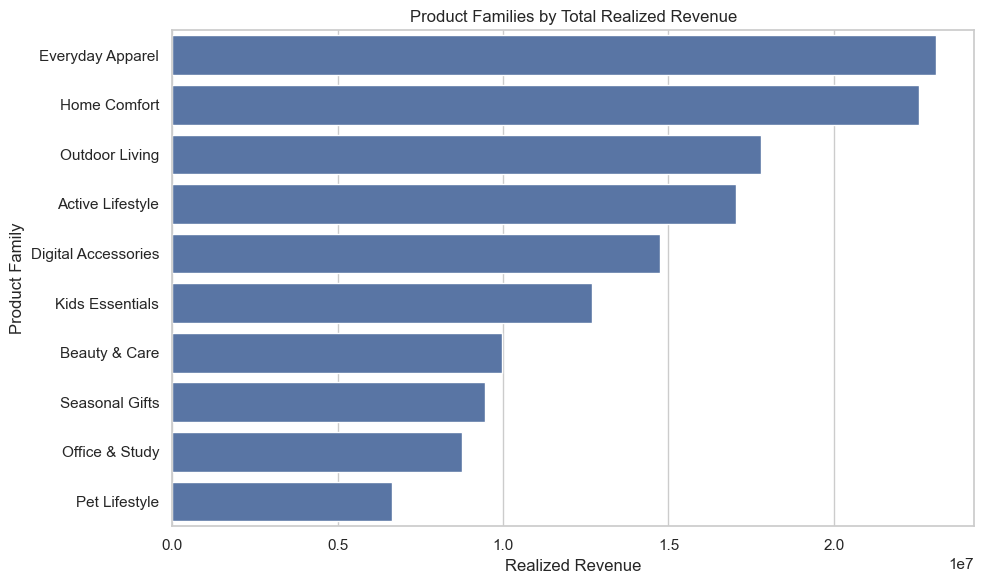

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=product_performance.reset_index(),
    x="total_realized_revenue",
    y=SCHEMA["product_category"]
)
plt.title("Product Families by Total Realized Revenue")
plt.xlabel("Realized Revenue")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()


**Everyday Apparel** is the largest realized-revenue driver, followed by **Home Comfort**, **Outdoor Living**, and **Active Lifestyle**. Everyday Apparel also carries the highest return rate, so its value depends on both scale and return control.

## 4.4 Monthly trends and seasonality

**Business question:** What does the monthly revenue trend reveal about seasonality, customer demand, and return behavior?

Monthly analysis helps identify peak periods, demand concentration, and seasonal return pressure. These patterns are also relevant for revenue forecasting.

In [28]:
monthly_trend = (
    analysis_df.groupby("order_month_period")
    .agg(
        order_lines=(SCHEMA["order_line_id"], "count"),
        total_net_revenue=(SCHEMA["original_revenue"], "sum"),
        total_realized_revenue=(SCHEMA["realized_revenue"], "sum"),
        return_rate=(SCHEMA["return_flag"], "mean"),
        unique_customers=(SCHEMA["customer_id"], "nunique")
    )
    .reset_index()
)

monthly_trend["month"] = pd.to_datetime(monthly_trend["order_month_period"])

display(monthly_trend)


,order_month_period,order_lines,total_net_revenue,total_realized_revenue,return_rate,unique_customers,month
0,2024-01,285408,"11,174,732.770","10,063,481.020",0.121,114852,2024-01-01
1,2024-02,259423,"10,233,308.360","9,421,241.140",0.093,106794,2024-02-01
2,2024-03,302321,"11,188,099.540","10,270,340.460",0.098,120282,2024-03-01
3,2024-04,316943,"12,289,876.480","11,342,761.310",0.091,124567,2024-04-01
4,2024-05,332916,"12,841,042.550","11,745,383.260",0.101,129365,2024-05-01
5,2024-06,318547,"11,671,436.250","10,622,996.310",0.109,125055,2024-06-01
6,2024-07,307243,"11,984,818.390","11,010,625.210",0.096,121828,2024-07-01
7,2024-08,344056,"12,709,045.470","11,592,585.050",0.106,133073,2024-08-01
8,2024-09,366945,"14,130,672.250","12,842,516.480",0.109,138762,2024-09-01
9,2024-10,394169,"14,461,153.810","13,088,504.210",0.115,146283,2024-10-01


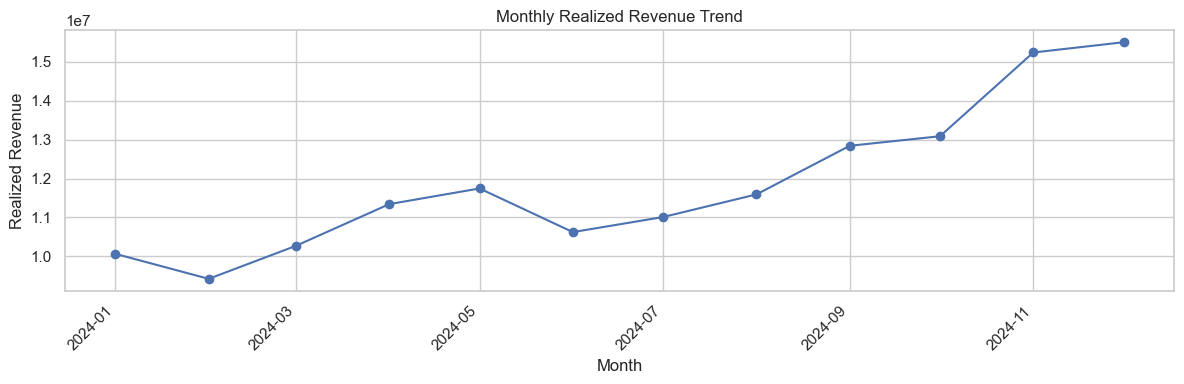

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_trend["month"], monthly_trend["total_realized_revenue"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Realized Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Realized Revenue")
plt.tight_layout()
plt.show()


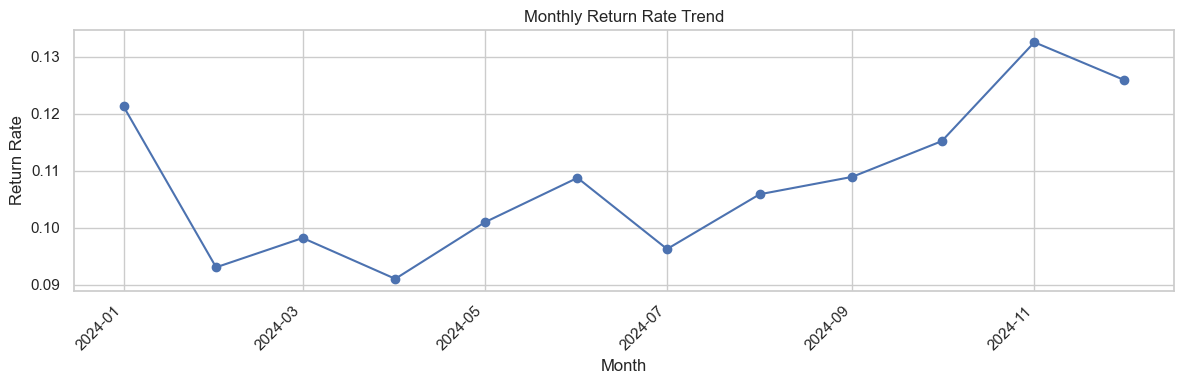

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_trend["month"], monthly_trend["return_rate"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Return Rate Trend")
plt.xlabel("Month")
plt.ylabel("Return Rate")
plt.tight_layout()
plt.show()


Realized revenue increases toward the end of the year, with the strongest months in **November** and **December**. Order-line volume and unique customers also rise during this period, showing clear seasonal demand concentration.

Return rates also increase in the peak months. Seasonal growth should therefore be planned together with return capacity, fulfillment readiness, and revenue forecasting.


## 4.5 Quantity analysis

**Business question:** How common are multi-quantity order lines, and how does quantity relate to realized revenue and return behavior?

Quantity analysis helps separate low-value single-item purchases from larger basket behavior and identifies whether larger quantities carry higher return risk.

,quantity
count,"4,262,864.000"
mean,1.511
std,0.972
min,1.000
50%,1.000
75%,2.000
90%,3.000
95%,4.000
99%,5.000
max,6.000


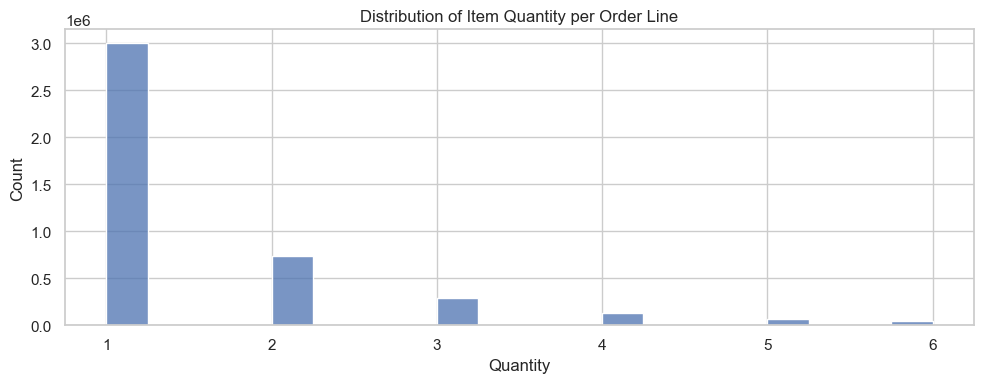

In [31]:
qty_summary = analysis_df[quantity_col].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame(name="quantity")
display(qty_summary)

plt.figure(figsize=(10, 4))
sns.histplot(analysis_df[quantity_col], bins=20)
plt.title("Distribution of Item Quantity per Order Line")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


,avg_quantity,median_quantity,total_quantity,order_lines
product_family,,,,
Office & Study,1.841,1.000,690615,375091
Pet Lifestyle,1.723,1.000,451422,262061
Seasonal Gifts,1.695,1.000,425721,251182
Beauty & Care,1.654,1.000,701548,424235
Digital Accessories,1.621,1.000,722250,445676
Kids Essentials,1.574,1.000,798904,507687
Everyday Apparel,1.423,1.000,1047248,735744
Active Lifestyle,1.345,1.000,577845,429749
Home Comfort,1.268,1.000,636670,502186


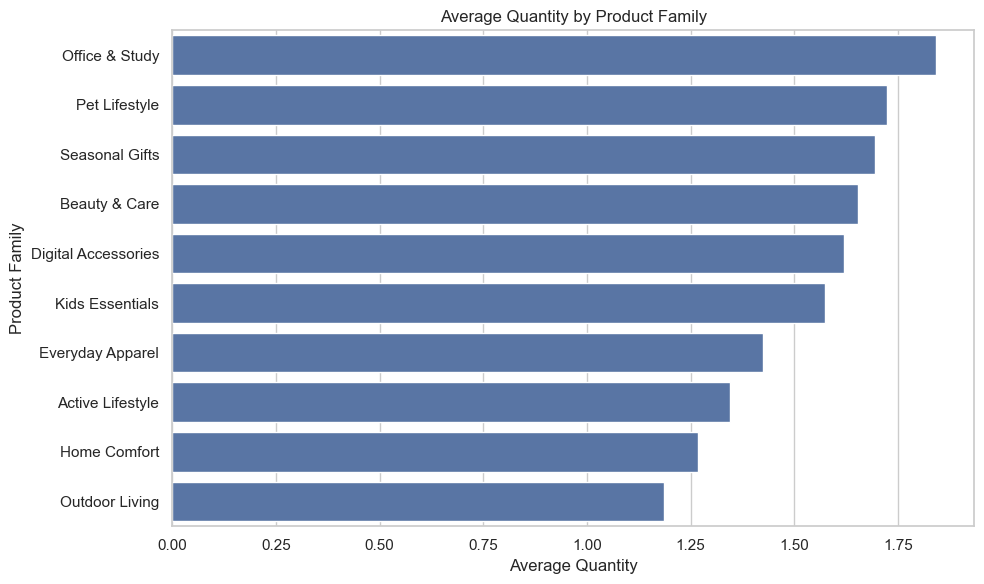

In [32]:
qty_by_family = (
    analysis_df.groupby(SCHEMA["product_category"], dropna=False)
    .agg(
        avg_quantity=(SCHEMA["quantity"], "mean"),
        median_quantity=(SCHEMA["quantity"], "median"),
        total_quantity=(SCHEMA["quantity"], "sum"),
        order_lines=(SCHEMA["order_line_id"], "count")
    )
    .sort_values("avg_quantity", ascending=False)
)

display(qty_by_family)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=qty_by_family.reset_index(),
    x="avg_quantity",
    y=SCHEMA["product_category"]
)
plt.title("Average Quantity by Product Family")
plt.xlabel("Average Quantity")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()


,lines,return_rate,avg_realized_revenue
quantity_bucket,,,
1,2995538,0.111,23.770
2,738439,0.107,42.302
3,289618,0.107,61.924
4-5,199493,0.112,87.898
6+,39776,0.118,121.635


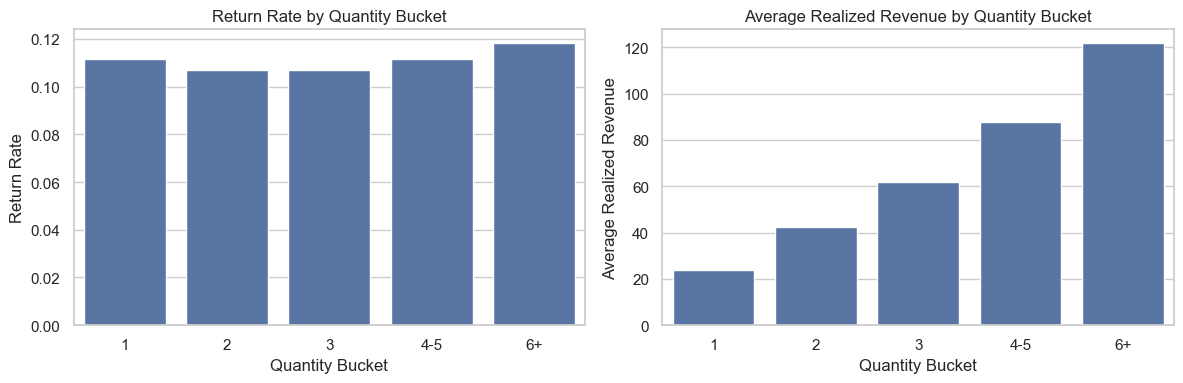

In [33]:
analysis_df["quantity_bucket"] = pd.cut(
    analysis_df[quantity_col],
    bins=[0, 1, 2, 3, 5, np.inf],
    labels=["1", "2", "3", "4-5", "6+"]
)

qty_behavior = (
    analysis_df.groupby("quantity_bucket", observed=False)
    .agg(
        lines=(SCHEMA["order_line_id"], "count"),
        return_rate=(SCHEMA["return_flag"], "mean"),
        avg_realized_revenue=(SCHEMA["realized_revenue"], "mean")
    )
)

display(qty_behavior)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=qty_behavior.reset_index(), x="quantity_bucket", y="return_rate", ax=axes[0])
axes[0].set_title("Return Rate by Quantity Bucket")
axes[0].set_xlabel("Quantity Bucket")
axes[0].set_ylabel("Return Rate")

sns.barplot(data=qty_behavior.reset_index(), x="quantity_bucket", y="avg_realized_revenue", ax=axes[1])
axes[1].set_title("Average Realized Revenue by Quantity Bucket")
axes[1].set_xlabel("Quantity Bucket")
axes[1].set_ylabel("Average Realized Revenue")

plt.tight_layout()
plt.show()


Most order lines contain a quantity of one, but higher-quantity lines produce substantially higher average realized revenue. Return rates stay fairly stable from quantities 1 to 5, then rise slightly for 6+ quantity lines. Multi-quantity orders look commercially valuable and are not necessarily riskier in most cases. Very high-quantity lines may still deserve separate monitoring because they combine higher value with slightly higher return behavior.


## 4.6 Acquisition channel and campaign analysis

**Business question:** Which acquisition channels bring the most order volume, realized revenue, and customer quality?

The analysis uses attribution fields such as:

- `acquisition_channel`
- `campaign_group`
- `traffic_source_group`

The goal is to compare channel scale, retained revenue, return behavior, and customer-level quality.


### 4.6.1 Channel-level volume and revenue

In [34]:
channel_summary = (
    analysis_df.groupby(SCHEMA["channel"], dropna=False)
    .agg(
        order_lines=(SCHEMA["order_line_id"], "count"),
        unique_customers=(SCHEMA["customer_id"], "nunique"),
        total_realized_revenue=(SCHEMA["realized_revenue"], "sum"),
        avg_realized_revenue=(SCHEMA["realized_revenue"], "mean"),
        return_rate=(SCHEMA["return_flag"], "mean")
    )
    .sort_values("order_lines", ascending=False)
)

display(channel_summary)


,order_lines,unique_customers,total_realized_revenue,avg_realized_revenue,return_rate
acquisition_channel,,,,,
direct_web,1002758,258903,"34,811,417.470",34.716,0.094
organic_search,756455,222308,"25,792,878.470",34.097,0.107
paid_search,694815,211734,"22,834,478.900",32.864,0.117
social_media,549281,183200,"17,583,961.540",32.013,0.137
email_campaign,546711,182373,"18,052,280.100",33.020,0.090
marketplace,372510,140084,"12,543,228.180",33.672,0.129
affiliate_partner,340334,131700,"11,129,577.350",32.702,0.121


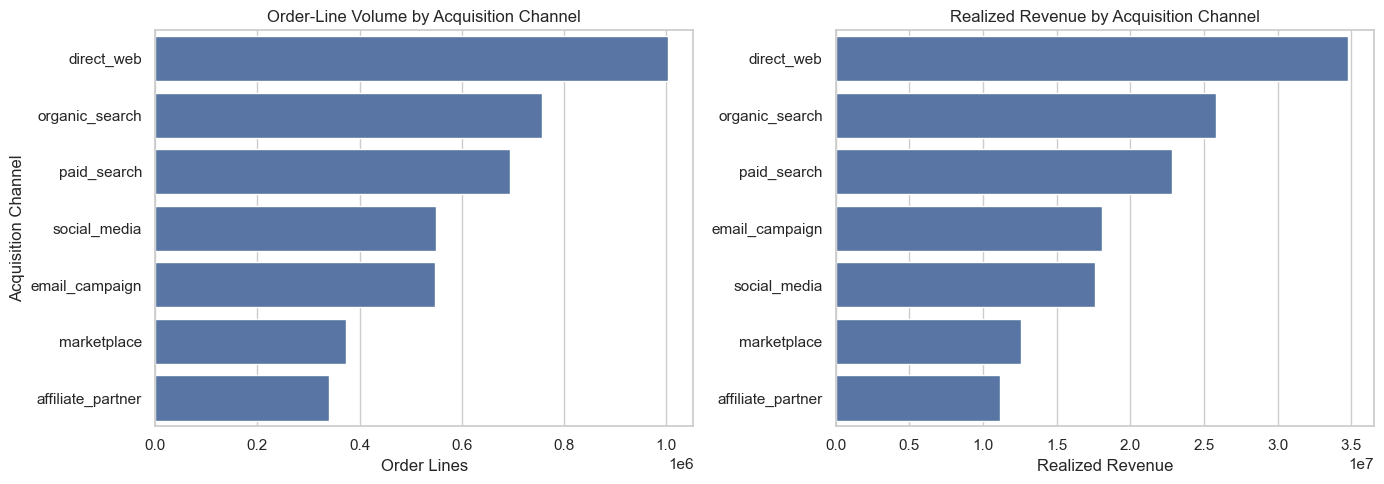

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=channel_summary.reset_index(),
    x="order_lines",
    y=SCHEMA["channel"],
    ax=axes[0]
)
axes[0].set_title("Order-Line Volume by Acquisition Channel")
axes[0].set_xlabel("Order Lines")
axes[0].set_ylabel("Acquisition Channel")

sns.barplot(
    data=channel_summary.sort_values("total_realized_revenue", ascending=False).reset_index(),
    x="total_realized_revenue",
    y=SCHEMA["channel"],
    ax=axes[1]
)
axes[1].set_title("Realized Revenue by Acquisition Channel")
axes[1].set_xlabel("Realized Revenue")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Direct web** is the strongest channel by order-line volume, customer count, and realized revenue. Organic search and paid search are also major contributors. Direct web also has a relatively low return rate, making it commercially attractive. Paid and social channels generate meaningful scale but should be monitored more closely because their return rates are higher.


### 4.6.2 Return behavior by channel and product family

acquisition_channel,affiliate_partner,direct_web,email_campaign,marketplace,organic_search,paid_search,social_media
product_family,,,,,,,
Active Lifestyle,0.135,0.108,0.102,0.144,0.123,0.132,0.152
Beauty & Care,0.082,0.054,0.050,0.088,0.067,0.079,0.098
Digital Accessories,0.075,0.048,0.042,0.080,0.059,0.070,0.091
Everyday Apparel,0.212,0.187,0.181,0.221,0.196,0.210,0.230
Home Comfort,0.107,0.081,0.076,0.114,0.092,0.104,0.124
Kids Essentials,0.130,0.102,0.098,0.137,0.116,0.127,0.148
Office & Study,0.058,0.033,0.031,0.066,0.043,0.053,0.072
Outdoor Living,0.125,0.101,0.093,0.138,0.114,0.122,0.142


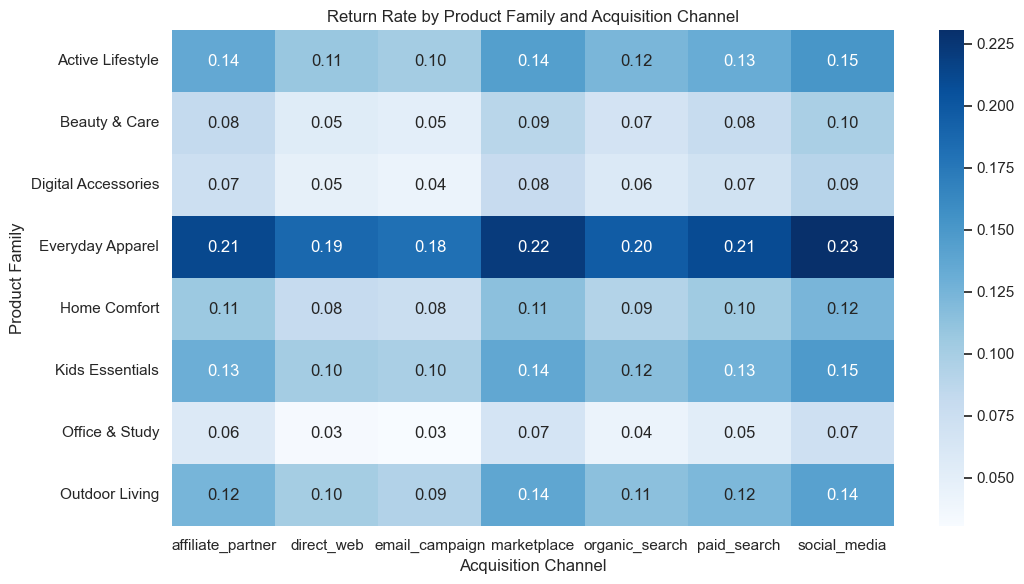

In [36]:
top_channels = channel_summary.head(7).index.tolist()
top_families = analysis_df[SCHEMA["product_category"]].value_counts().head(8).index.tolist()

channel_family_return = (
    analysis_df[
        analysis_df[SCHEMA["channel"]].isin(top_channels) &
        analysis_df[SCHEMA["product_category"]].isin(top_families)
    ]
    .groupby([SCHEMA["product_category"], SCHEMA["channel"]])[SCHEMA["return_flag"]]
    .mean()
    .unstack(fill_value=0)
)

display(channel_family_return)

plt.figure(figsize=(11, 6))
sns.heatmap(channel_family_return, annot=True, fmt=".2f", cmap="Blues")
plt.title("Return Rate by Product Family and Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()


The heatmap shows that return risk is not evenly distributed. Everyday Apparel has high return rates across all channels, especially social media and marketplace. Office & Study and Digital Accessories show consistently lower return behavior. This supports targeted return-risk controls at the product-family and channel intersection, rather than one broad return policy.


### 4.6.3 Campaign and traffic-source behavior

,order_lines,total_realized_revenue,avg_realized_revenue,return_rate
campaign_group,,,,
always_on,1472157,"57,960,118.930",39.371,0.101
holiday_peak,679154,"19,441,868.550",28.627,0.130
clearance,499071,"11,982,717.420",24.010,0.116
new_customer_offer,354305,"11,001,747.230",31.052,0.112
autumn_savings,316241,"10,574,457.910",33.438,0.110
spring_refresh,301959,"10,215,828.810",33.832,0.107
summer_event,301647,"9,918,011.680",32.880,0.109
back_to_routine,295844,"10,226,753.060",34.568,0.108
Unknown,42486,"1,426,318.420",33.571,0.110


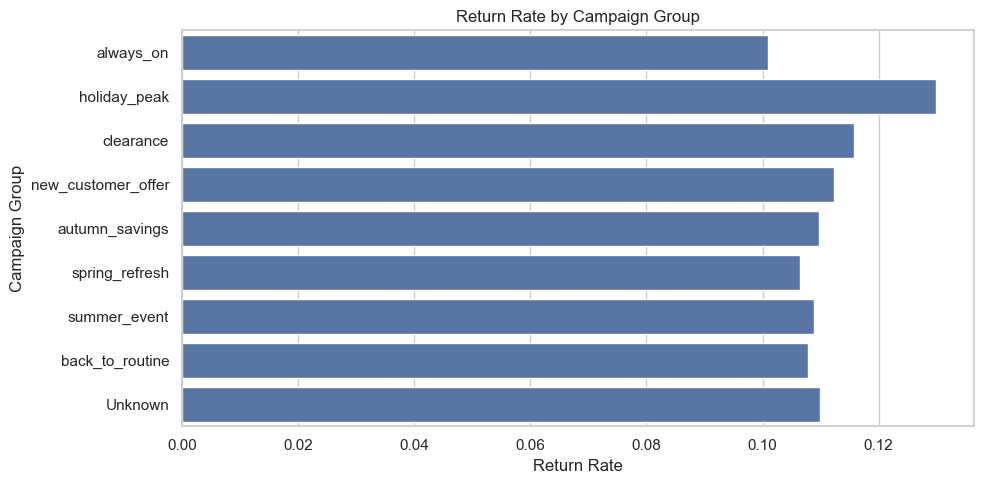

In [37]:
campaign_summary = (
    analysis_df.groupby(SCHEMA["campaign"], dropna=False)
    .agg(
        order_lines=(SCHEMA["order_line_id"], "count"),
        total_realized_revenue=(SCHEMA["realized_revenue"], "sum"),
        avg_realized_revenue=(SCHEMA["realized_revenue"], "mean"),
        return_rate=(SCHEMA["return_flag"], "mean")
    )
    .sort_values("order_lines", ascending=False)
)

display(campaign_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=campaign_summary.reset_index(),
    x="return_rate",
    y=SCHEMA["campaign"]
)
plt.title("Return Rate by Campaign Group")
plt.xlabel("Return Rate")
plt.ylabel("Campaign Group")
plt.tight_layout()
plt.show()


In [38]:
traffic_summary = (
    analysis_df.groupby(SCHEMA["traffic_source"], dropna=False)
    .agg(
        order_lines=(SCHEMA["order_line_id"], "count"),
        total_realized_revenue=(SCHEMA["realized_revenue"], "sum"),
        return_rate=(SCHEMA["return_flag"], "mean")
    )
    .sort_values("order_lines", ascending=False)
)

display(traffic_summary)


,order_lines,total_realized_revenue,return_rate
traffic_source_group,,,
social_feed,601212,"20,143,652.170",0.111
type_in,600222,"20,078,821.830",0.110
search_engine,599930,"20,105,851.100",0.111
newsletter,599731,"20,089,758.500",0.110
partner_site,599726,"20,089,261.860",0.111
comparison_site,599526,"20,079,151.650",0.110
retargeting,598883,"20,025,782.040",0.110
Unknown,63634,"2,135,542.860",0.109


The `always_on` campaign group contributes the largest realized revenue and volume, while `holiday_peak` shows a higher return rate. Traffic-source groups are broadly balanced in volume and return behavior, suggesting that acquisition channel and campaign type are more informative than traffic-source group alone. For planning, seasonal campaigns should be evaluated by realized revenue after returns, not just gross demand.


### 4.6.4 Channel vs. customer quality

This view compares channels by realized revenue per customer and customer-level return behavior, not only by traffic or order-line count.


In [39]:
customer_channel_quality = (
    analysis_df.groupby([SCHEMA["channel"], SCHEMA["customer_id"]])
    .agg(
        customer_realized_revenue=(SCHEMA["realized_revenue"], "sum"),
        customer_order_lines=(SCHEMA["order_line_id"], "count"),
        customer_return_rate=(SCHEMA["return_flag"], "mean")
    )
    .reset_index()
)

channel_quality = (
    customer_channel_quality.groupby(SCHEMA["channel"])
    .agg(
        customers=(SCHEMA["customer_id"], "nunique"),
        avg_customer_revenue=("customer_realized_revenue", "mean"),
        median_customer_revenue=("customer_realized_revenue", "median"),
        avg_customer_return_rate=("customer_return_rate", "mean")
    )
    .sort_values("avg_customer_revenue", ascending=False)
)

display(channel_quality)


,customers,avg_customer_revenue,median_customer_revenue,avg_customer_return_rate
acquisition_channel,,,,
direct_web,258903,134.457,89.540,0.098
organic_search,222308,116.023,77.660,0.109
paid_search,211734,107.845,71.960,0.120
email_campaign,182373,98.985,66.880,0.092
social_media,183200,95.982,64.090,0.140
marketplace,140084,89.541,60.400,0.131
affiliate_partner,131700,84.507,57.095,0.122


Direct web has the highest average customer revenue and the largest customer base. Email campaign shows comparatively low customer-level return behavior, while social media and marketplace have higher average customer return rates. This suggests that customer acquisition strategy should consider customer quality and return behavior, not only acquisition volume or campaign reach.


## 4.7 Price vs. return behavior

**Business question:** Are higher-priced items associated with higher return rates?

Price sensitivity matters because higher-value products often come with stronger customer expectations and a larger financial impact when returned.

,return_rate,avg_price,lines
price_bucket,,,
"(0.231, 7.706]",0.095,4.878,852573
"(7.706, 13.31]",0.101,10.446,852626
"(13.31, 20.46]",0.109,16.683,852661
"(20.46, 32.44]",0.114,25.752,852676
"(32.44, 437.43]",0.134,51.166,852328


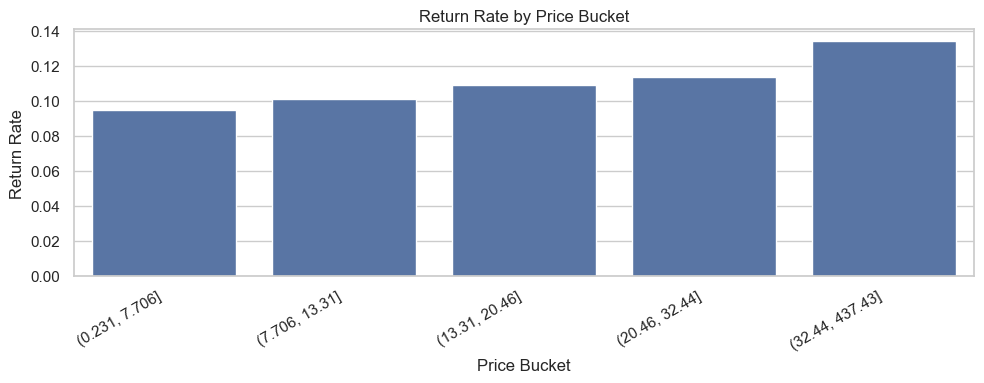

In [40]:
analysis_df["price_bucket"] = pd.qcut(
    analysis_df["price_per_item"],
    q=5,
    duplicates="drop"
)

price_return_table = (
    analysis_df.groupby("price_bucket", observed=False)
    .agg(
        return_rate=(SCHEMA["return_flag"], "mean"),
        avg_price=("price_per_item", "mean"),
        lines=(SCHEMA["order_line_id"], "count")
    )
)

display(price_return_table)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=price_return_table.reset_index(),
    x="price_bucket",
    y="return_rate"
)
plt.title("Return Rate by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Return Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Return rate rises across price buckets, from **9.5%** in the lowest price bucket to **13.4%** in the highest price bucket. Higher-priced items therefore carry higher return exposure. This has practical implications for product pages, customer support, sizing guidance, quality assurance, and return prediction features.


## 4.8 Delivery timing and return behavior

**Business question:** Does slower delivery correspond to higher return rates or lower retained revenue?

Delivery timing is reviewed as an operational signal that may influence customer satisfaction and return behavior.

,return_rate,avg_realized_revenue,lines
shipping_delay_bucket,,,
0-1 days,0.097,33.667,234272
2-3 days,0.097,33.891,1200228
4-5 days,0.111,33.451,2055398
6-10 days,0.133,32.897,772489
11-30 days,0.168,32.411,477
30+ days,NaN,NaN,0


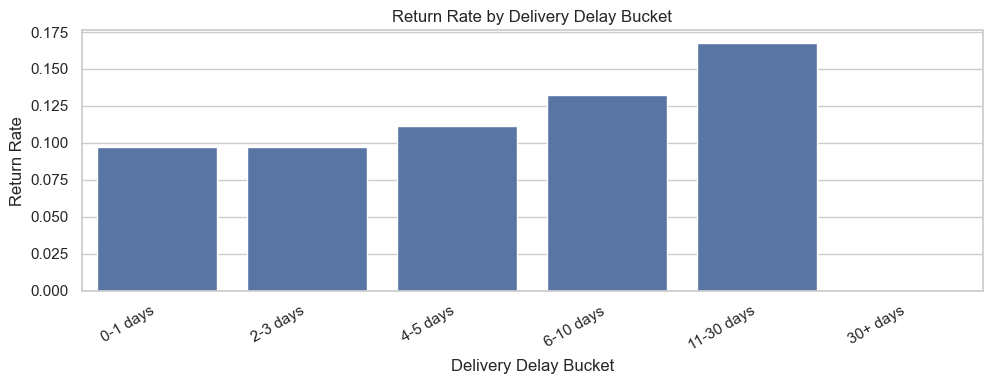

In [41]:
shipping_delay_col = SCHEMA["shipping_delay"]

shipping_analysis = analysis_df.dropna(subset=[shipping_delay_col]).copy()

shipping_analysis["shipping_delay_bucket"] = pd.cut(
    shipping_analysis[shipping_delay_col],
    bins=[-1, 1, 3, 5, 10, 30, np.inf],
    labels=["0-1 days", "2-3 days", "4-5 days", "6-10 days", "11-30 days", "30+ days"]
)

shipping_return_table = (
    shipping_analysis.groupby("shipping_delay_bucket", observed=False)
    .agg(
        return_rate=(SCHEMA["return_flag"], "mean"),
        avg_realized_revenue=(SCHEMA["realized_revenue"], "mean"),
        lines=(SCHEMA["order_line_id"], "count")
    )
)

display(shipping_return_table)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=shipping_return_table.reset_index(),
    x="shipping_delay_bucket",
    y="return_rate"
)
plt.title("Return Rate by Delivery Delay Bucket")
plt.xlabel("Delivery Delay Bucket")
plt.ylabel("Return Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Return rates are lowest around short delivery delays and increase as delays become longer. Lines with **6–10 day** delays show a return rate of **13.3%**, while **11–30 day** delays show **16.8%**. This suggests that fulfillment timing is not only an operational metric. It can also reflect customer experience and should be considered in return analysis.


## 4.9 Delivery performance

**Business question:** Which delivery modes or fulfillment partners show stronger operational performance?

This section reviews delivery-delay distribution, fulfillment partner consistency, and delivery-mode return behavior.

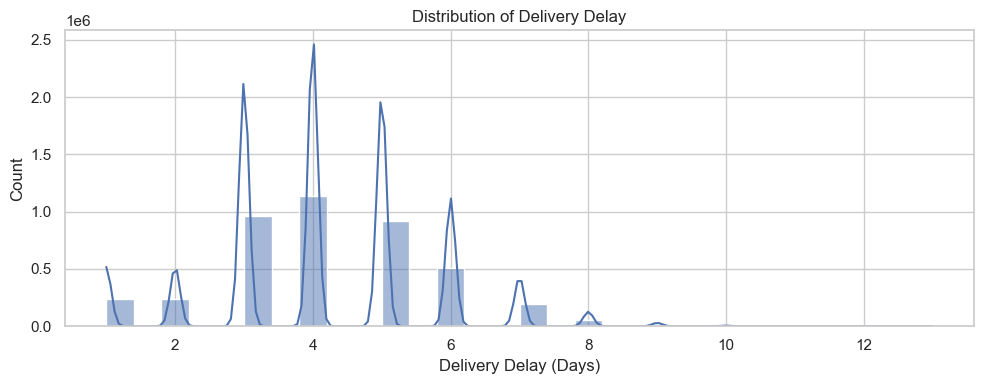

In [42]:
plt.figure(figsize=(10, 4))
sns.histplot(analysis_df[shipping_delay_col], bins=30, kde=True)
plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay (Days)")
plt.tight_layout()
plt.show()


,avg_delivery_delay,median_delivery_delay,return_rate,lines
fulfillment_partner,,,,
ParcelSwift,4.158,4.000,0.110,704838
NorthStar Logistics,4.160,4.000,0.110,709483
MetroFulfill,4.161,4.000,0.111,706375
BoxBridge,4.162,4.000,0.111,708664
EcoShip,4.163,4.000,0.110,704881
UrbanRoute,4.164,4.000,0.110,707433
Unknown,4.179,4.000,0.111,21190


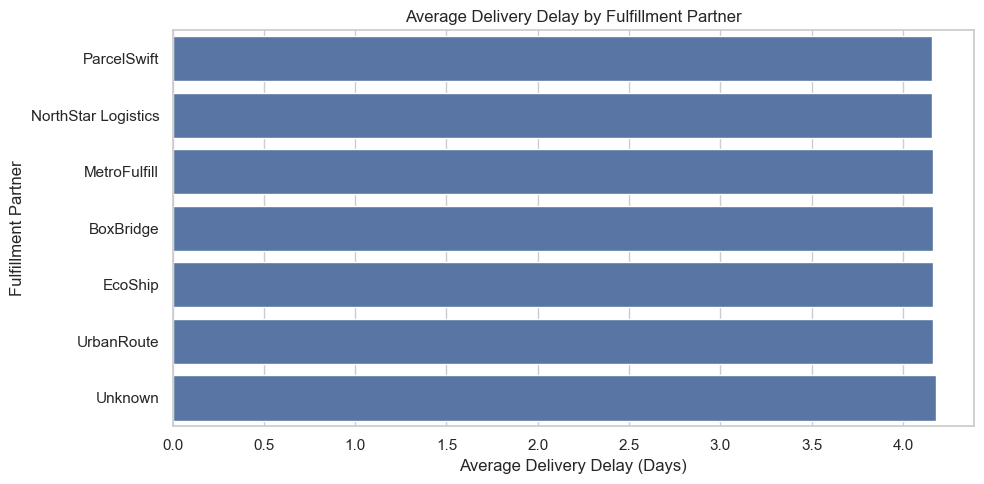

In [43]:
carrier_delay = (
    analysis_df.groupby(SCHEMA["carrier"], dropna=False)
    .agg(
        avg_delivery_delay=(SCHEMA["shipping_delay"], "mean"),
        median_delivery_delay=(SCHEMA["shipping_delay"], "median"),
        return_rate=(SCHEMA["return_flag"], "mean"),
        lines=(SCHEMA["order_line_id"], "count")
    )
    .sort_values("avg_delivery_delay")
)

display(carrier_delay)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=carrier_delay.reset_index(),
    x="avg_delivery_delay",
    y=SCHEMA["carrier"]
)
plt.title("Average Delivery Delay by Fulfillment Partner")
plt.xlabel("Average Delivery Delay (Days)")
plt.ylabel("Fulfillment Partner")
plt.tight_layout()
plt.show()


In [44]:
if "delivery_mode" in analysis_df.columns:
    delivery_mode_summary = (
        analysis_df.groupby("delivery_mode")
        .agg(
            lines=(SCHEMA["order_line_id"], "count"),
            avg_delivery_delay=(SCHEMA["shipping_delay"], "mean"),
            return_rate=(SCHEMA["return_flag"], "mean"),
            realized_revenue=(SCHEMA["realized_revenue"], "sum")
        )
        .sort_values("lines", ascending=False)
    )

    display(delivery_mode_summary)


,lines,avg_delivery_delay,return_rate,realized_revenue
delivery_mode,,,,
standard,1963553,4.000,0.107,"65,970,966.750"
pickup_point,681326,4.999,0.118,"22,675,357.360"
economy,640226,6.001,0.128,"21,132,761.840"
express,637125,2.000,0.098,"21,518,802.180"
locker,340634,4.000,0.106,"11,449,933.880"


Fulfillment partners have very similar average delivery delays and return rates, suggesting no major partner-level performance gap. Delivery mode shows clearer differences: express has the shortest average delay and a lower return rate, while economy and pickup-point modes show higher return rates.

## 4.10 RFM-R customer segmentation

**Business question:** Which customers create retained value, and where does return behavior change the customer view?

Traditional RFM segmentation looks at recency, frequency, and monetary value. I extend that view with return behavior, so customers are not judged only by what they buy, but also by how much value remains after returns. That distinction matters in e-commerce: a customer can look valuable from purchase revenue alone while still creating margin pressure through frequent returns.

### 4.10.1 Customer-level RFM-R base table

The customer table aggregates order-line behavior into a customer-level view. It combines how recently each customer ordered, how often they placed retained orders, how much realized revenue they generated, and how much of their activity was returned.

In [45]:
customer_lines = analysis_df.dropna(subset=[SCHEMA["customer_id"], SCHEMA["order_date"]]).copy()

# Order-level validity: an order is valid if it has at least one non-returned line.
order_validity = (
    customer_lines.groupby([SCHEMA["customer_id"], SCHEMA["order_id"]])
    .agg(
        order_date=(SCHEMA["order_date"], "max"),
        has_non_returned_item=(SCHEMA["return_flag"], lambda x: int((x == 0).any()))
    )
    .reset_index()
)

customer_frequency = (
    order_validity.groupby(SCHEMA["customer_id"])["has_non_returned_item"]
    .sum()
    .rename("frequency")
)

snapshot_date = customer_lines[SCHEMA["order_date"]].max() + pd.Timedelta(days=1)

rfmr_base = (
    customer_lines.groupby(SCHEMA["customer_id"])
    .agg(
        last_order_date=(SCHEMA["order_date"], "max"),
        first_order_date=(SCHEMA["order_date"], "min"),
        total_order_lines=(SCHEMA["order_line_id"], "count"),
        returned_order_lines=(SCHEMA["return_flag"], "sum"),
        monetary=(SCHEMA["realized_revenue"], "sum"),
        gross_monetary=(SCHEMA["original_revenue"], "sum")
    )
    .join(customer_frequency, how="left")
)

rfmr_base["recency"] = (snapshot_date - rfmr_base["last_order_date"]).dt.days
rfmr_base["return_rate"] = np.where(
    rfmr_base["total_order_lines"] > 0,
    rfmr_base["returned_order_lines"] / rfmr_base["total_order_lines"],
    np.nan
)
rfmr_base["customer_age_days"] = (snapshot_date - rfmr_base["first_order_date"]).dt.days

rfmr = rfmr_base[["recency", "frequency", "monetary", "return_rate", "customer_age_days"]].copy()
rfmr = rfmr.replace([np.inf, -np.inf], np.nan).dropna(subset=["recency", "frequency", "monetary", "return_rate"])

display(rfmr.head())
print("RFM-R customer table shape:", rfmr.shape)


,recency,frequency,monetary,return_rate,customer_age_days
customer_key,,,,,
CUST-00000001,239,2,105.440,0.000,338
CUST-00000002,150,1,30.520,0.000,150
CUST-00000003,130,1,26.040,0.333,130
CUST-00000004,44,9,635.050,0.000,326
CUST-00000005,34,1,107.870,0.250,34


RFM-R customer table shape: (430113, 5)


### 4.10.2 Distribution before scoring

Before scoring, the raw RFM-R variables are checked for skew and discreteness. This matters because customer behavior is rarely evenly distributed: most customers buy occasionally, while a smaller group orders often and generates higher retained value.

In [46]:
rfmr[["recency", "frequency", "monetary", "return_rate"]].describe().transpose()


,count,mean,std,min,25%,50%,75%,max
recency,"430,113.000",77.222,84.987,1.000,16.000,43.000,108.000,366.000
frequency,"430,113.000",4.922,5.077,0.000,2.000,3.000,6.000,99.000
monetary,"430,113.000",331.884,370.094,0.000,87.890,212.330,440.490,"7,833.510"
return_rate,"430,113.000",0.115,0.168,0.000,0.000,0.062,0.167,1.000


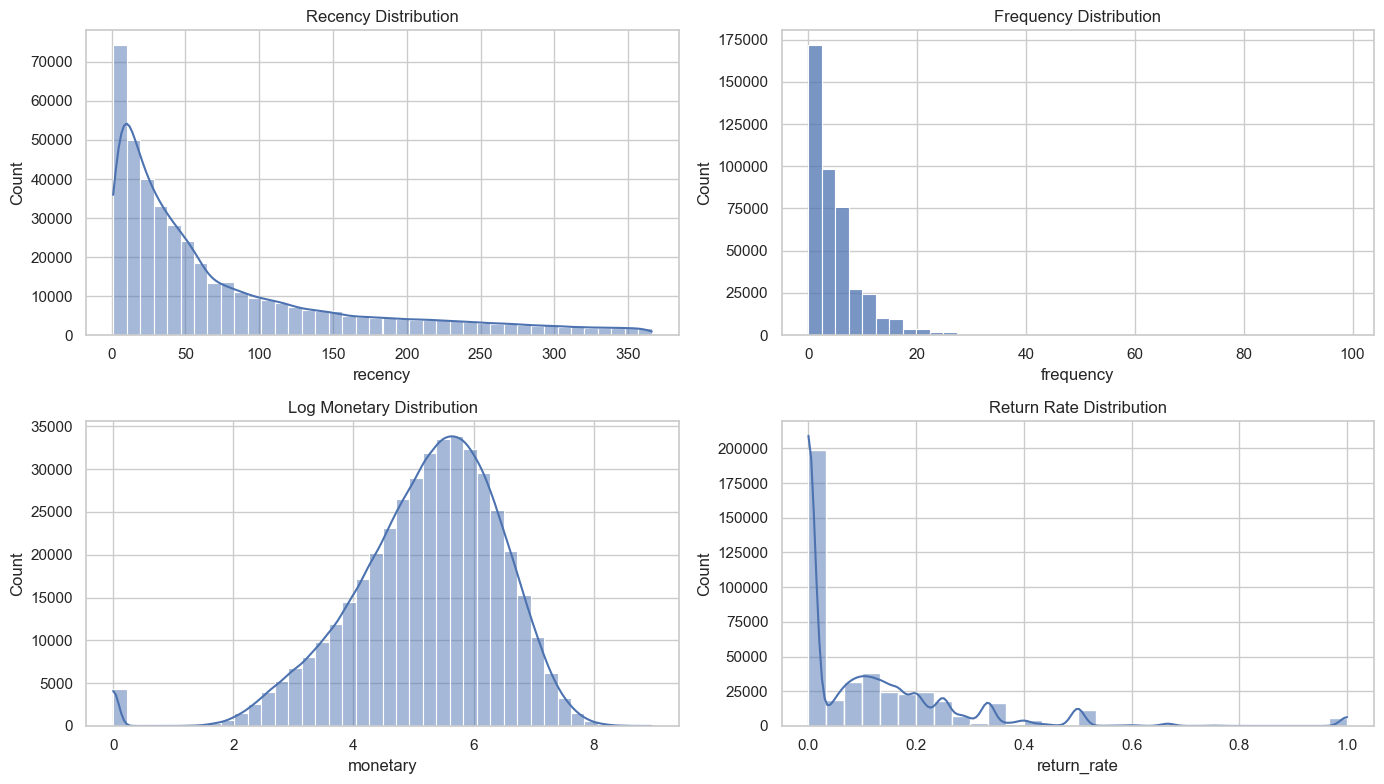

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(rfmr["recency"], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Recency Distribution")

sns.histplot(rfmr["frequency"], bins=40, kde=False, ax=axes[0, 1])
axes[0, 1].set_title("Frequency Distribution")

sns.histplot(np.log1p(rfmr["monetary"]), bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Log Monetary Distribution")

sns.histplot(rfmr["return_rate"], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Return Rate Distribution")

plt.tight_layout()
plt.show()


The customer profile is skewed in a realistic way. Many customers have modest frequency and monetary value, while a smaller group contributes much higher activity and retained revenue.

The median frequency is **3**, with some customers reaching much higher repeat activity. This suggests a broad customer base with a smaller high-value layer. Return behavior still needs to be included before treating high-spend customers as truly profitable.

### 4.10.3 Adaptive scoring

The RFM-R scores use adaptive scoring rather than simple rank-based quantiles. This choice avoids a common problem in customer segmentation: when a variable is skewed or has many repeated values, standard ranking can split identical raw values into different score groups. That would be difficult to explain and can create unrealistic segment boundaries. The issue is especially visible for return behavior. Many customers have a `return_rate` of exactly `0`, and those customers should not be split across different return scores. The adaptive approach keeps identical values together while still adjusting to the observed distribution.

Scoring direction:

- lower recency receives a higher score
- higher frequency receives a higher score
- higher monetary value receives a higher score
- lower return rate receives a higher score

In [48]:
# Split RFM-R base table into eligible and full-return customer groups.
# Full-return customers are kept for segmentation, but not adaptive-scored in the same way
# because they have no retained monetary value.
valid_rfmr = rfmr[~((rfmr["frequency"] == 0) & (rfmr["monetary"] == 0))].copy()
invalid_rfmr = rfmr[(rfmr["frequency"] == 0) & (rfmr["monetary"] == 0)].copy()

print("Eligible customers for adaptive RFM-R scoring:", valid_rfmr.shape[0])
print("Full-return customers kept as a separate group:", invalid_rfmr.shape[0])


def adaptive_score(series, n_bins=5, reverse=False, dominance_threshold=0.50):
    """
    Adaptive scoring for skewed / discrete variables.

    Rules:
    1. Try value-based quantile scoring on raw values.
       This keeps identical values together.
    2. If one value dominates too much, fall back to scoring unique ordered values
       by their percentile position.
       This is especially useful for return_rate where many customers may have 0.
    """
    s = series.copy()

    if s.dropna().empty:
        return pd.Series(pd.array([pd.NA] * len(s), dtype="Int64"), index=s.index)

    value_share = s.value_counts(dropna=True, normalize=True)
    top_share = value_share.iloc[0] if len(value_share) > 0 else 0

    def labels_for(reverse=False):
        return list(range(n_bins, 0, -1)) if reverse else list(range(1, n_bins + 1))

    # First try value-based quantile scoring.
    # Unlike rank(method="first"), this does not split identical raw values.
    if top_share <= dominance_threshold:
        try:
            scored = pd.qcut(
                s,
                q=n_bins,
                labels=labels_for(reverse=reverse),
                duplicates="drop"
            )
            return scored.astype("Int64")
        except Exception:
            pass

    # Fallback: score unique values.
    # Same values always map to the same score.
    unique_values = np.sort(s.dropna().unique())

    if reverse:
        unique_values = unique_values[::-1]

    positions = np.linspace(0, n_bins, len(unique_values), endpoint=False)
    mapped_scores = np.floor(positions).astype(int) + 1
    mapped_scores = np.clip(mapped_scores, 1, n_bins)

    value_to_score = {
        value: int(score)
        for value, score in zip(unique_values, mapped_scores)
    }

    scored = s.map(value_to_score).astype("Int64")
    return scored


# Apply adaptive scoring.
# reverse=True means lower values receive higher scores.
valid_rfmr["R_score"] = adaptive_score(valid_rfmr["recency"], reverse=True)
valid_rfmr["F_score"] = adaptive_score(valid_rfmr["frequency"], reverse=False)
valid_rfmr["M_score"] = adaptive_score(valid_rfmr["monetary"], reverse=False)
valid_rfmr["Rr_score"] = adaptive_score(valid_rfmr["return_rate"], reverse=True)

# Full-return customers remain in the final segmentation table but receive score 0.
# This keeps them visible without mixing them into retained-value customer scoring.
if not invalid_rfmr.empty:
    invalid_rfmr[["R_score", "F_score", "M_score", "Rr_score"]] = 0

rfmr = pd.concat([valid_rfmr, invalid_rfmr], axis=0)

rfmr["RFMR_score"] = (
    rfmr["R_score"].astype(str) +
    rfmr["F_score"].astype(str) +
    rfmr["M_score"].astype(str) +
    rfmr["Rr_score"].astype(str)
)

display(rfmr.head())


Eligible customers for adaptive RFM-R scoring: 425825
Full-return customers kept as a separate group: 4288


,recency,frequency,monetary,return_rate,customer_age_days,R_score,F_score,M_score,Rr_score,RFMR_score
customer_key,,,,,,,,,,
CUST-00000001,239,2,105.440,0.000,338,1,2,2,5,1225
CUST-00000002,150,1,30.520,0.000,150,1,1,1,5,1115
CUST-00000003,130,1,26.040,0.333,130,2,1,1,1,2111
CUST-00000004,44,9,635.050,0.000,326,3,5,5,5,3555
CUST-00000005,34,1,107.870,0.250,34,3,1,2,2,3122


#### Score ranges and customer distribution

The tables below show the raw value ranges behind each score. They act as a quick quality check for the scoring logic.The key point is explainability: customers with the same raw value stay in the same score group. The return-rate check confirms that customers with `return_rate = 0` all receive the same best return score.

In [49]:
score_cols = {
    "recency": "R_score",
    "frequency": "F_score",
    "monetary": "M_score",
    "return_rate": "Rr_score"
}


def score_range_summary(df, value_col, score_col):
    """Summarize raw value ranges behind each adaptive score."""
    summary = (
        df.groupby(score_col, dropna=False)
        .agg(
            min_value=(value_col, "min"),
            max_value=(value_col, "max"),
            total_rows=(value_col, "size")
        )
        .reset_index()
        .sort_values(score_col)
    )

    summary["range_text"] = (
        summary["min_value"].round(4).astype(str) +
        " ~ " +
        summary["max_value"].round(4).astype(str)
    )

    return summary[[score_col, "range_text", "total_rows", "min_value", "max_value"]]


score_summaries = {}

for value_col, score_col in score_cols.items():
    summary = score_range_summary(valid_rfmr, value_col, score_col)
    score_summaries[value_col] = summary

    print(f"\n=== {value_col.upper()} ===")
    display(summary[[score_col, "range_text", "total_rows"]])

# Explicit validation for the return-rate issue:
if "return_rate" in valid_rfmr.columns:
    zero_return_scores = valid_rfmr.loc[valid_rfmr["return_rate"] == 0, "Rr_score"].dropna().unique()
    print("\nScores assigned to customers with return_rate = 0:", sorted(zero_return_scores.tolist()))



=== RECENCY ===


,R_score,range_text,total_rows
0,1,133 ~ 366,84841
1,2,59 ~ 132,85462
2,3,31 ~ 58,84077
3,4,13 ~ 30,85236
4,5,1 ~ 12,86209



=== FREQUENCY ===


,F_score,range_text,total_rows
0,1,0 ~ 1,92714
1,2,2 ~ 3,131073
2,3,4 ~ 4,41969
3,4,5 ~ 7,75612
4,5,8 ~ 99,84457



=== MONETARY ===


,M_score,range_text,total_rows
0,1,1.37 ~ 71.84,85173
1,2,71.85 ~ 158.5,85166
2,3,158.51 ~ 286.26,85160
3,4,286.27 ~ 522.27,85162
4,5,522.28 ~ 7833.51,85164



=== RETURN_RATE ===


,Rr_score,range_text,total_rows
0,1,0.2647 ~ 1.0,48228
1,2,0.1562 ~ 0.2632,67763
2,3,0.1068 ~ 0.1558,49649
3,4,0.068 ~ 0.1067,39240
4,5,0.0 ~ 0.068,220945



Scores assigned to customers with return_rate = 0: [5]


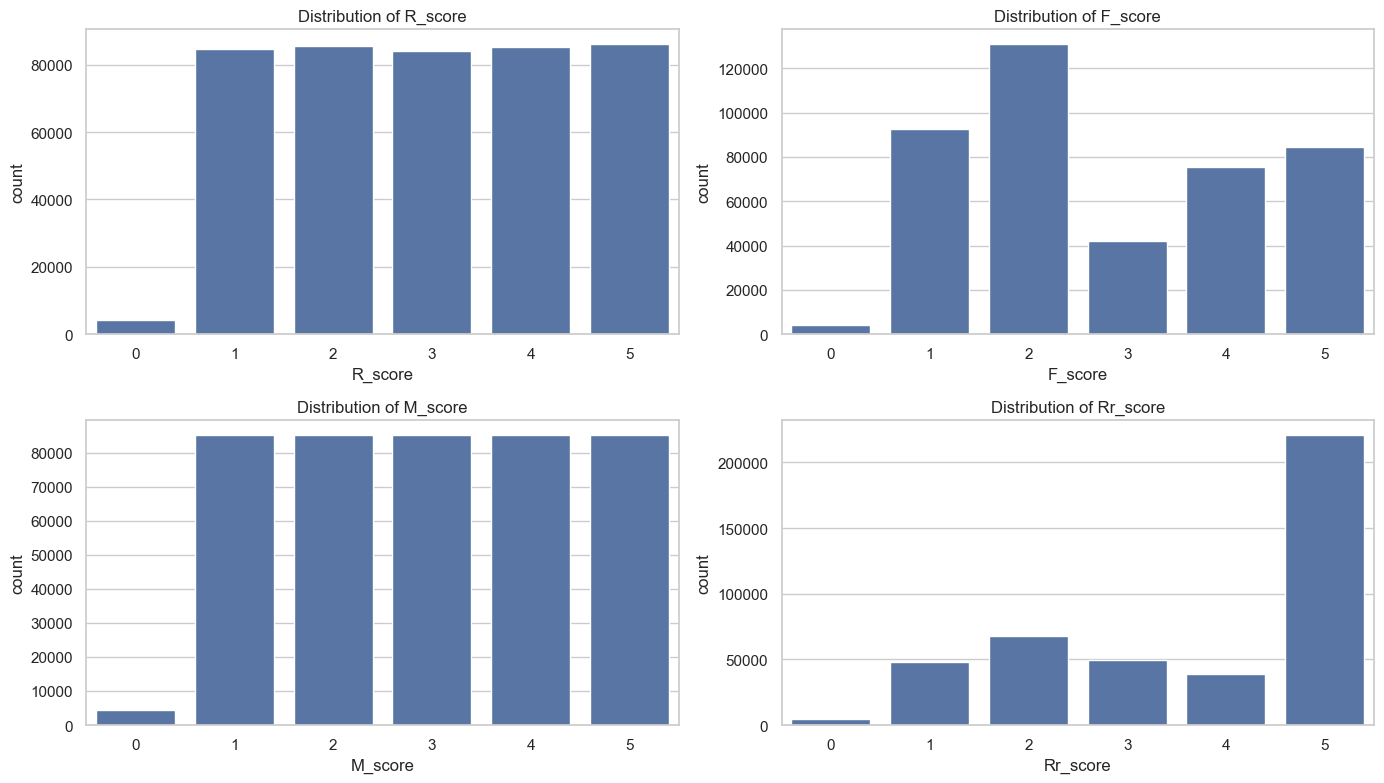

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, score_col in zip(axes.flatten(), ["R_score", "F_score", "M_score", "Rr_score"]):
    sns.countplot(data=rfmr, x=score_col, ax=ax)
    ax.set_title(f"Distribution of {score_col}")

plt.tight_layout()
plt.show()


### 4.10.4 Customer segments

The segment rules combine value, activity, recency, and return behavior into groups that can be used for CRM, retention, and profitability analysis.

Segment meanings:

- **Champions**: recent, frequent, high-value customers with relatively healthy return behavior
- **Loyal Value Customers**: repeat customers with strong retained value and acceptable return behavior
- **New / Promising**: recent customers who are still early in the relationship
- **High Return Risk**: customers with value, but return behavior that may reduce profitability
- **At Risk**: customers with past value but weaker recent activity
- **Hibernating / Lost**: inactive or low-value customers
- **Regular Customers**: customers with steady but less distinctive behavior
- **Full Return Customers**: customers whose observed purchases did not generate retained revenue

,customers,avg_recency,avg_frequency,avg_monetary,avg_return_rate
segment,,,,,
High Return Risk,95932,60.424,4.677,320.528,0.258
Hibernating / Lost,88399,181.449,1.402,62.502,0.062
Regular Customers,87620,28.447,5.371,359.323,0.105
Loyal Value Customers,57757,39.784,7.192,473.847,0.041
At Risk,38386,134.924,3.155,281.187,0.038
Champions,32308,11.436,15.059,"1,056.978",0.058
New / Promising,25423,15.199,1.996,105.397,0.001
Full Return Customers,4288,152.102,0.000,0.000,1.000


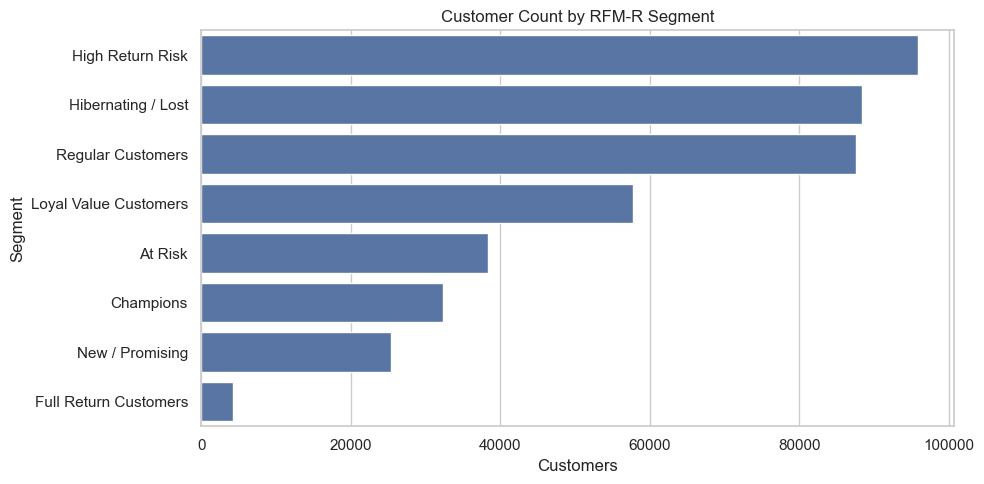

In [51]:
def map_rfmr_segment(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])
    rr = int(row["Rr_score"])

    if row["frequency"] == 0 and row["monetary"] == 0:
        return "Full Return Customers"

    elif r >= 4 and f >= 5 and m >= 5 and rr >= 4:
        return "Champions"

    elif f >= 4 and m >= 3 and rr >= 4:
        return "Loyal Value Customers"

    elif r >= 4 and f <= 2 and m <= 3 and rr >= 4:
        return "New / Promising"

    elif rr <= 2 and m >= 2:
        return "High Return Risk"

    elif r <= 2 and (f >= 3 or m >= 3):
        return "At Risk"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernating / Lost"

    else:
        return "Regular Customers"

rfmr["segment"] = rfmr.apply(map_rfmr_segment, axis=1)

rfmr_segment_summary = (
    rfmr.groupby("segment")
    .agg(
        customers=("segment", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_return_rate=("return_rate", "mean")
    )
    .sort_values("customers", ascending=False)
)

display(rfmr_segment_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=rfmr_segment_summary.reset_index(),
    x="customers",
    y="segment"
)
plt.title("Customer Count by RFM-R Segment")
plt.xlabel("Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()


#### What the RFM-R segments show

The segment table separates customer value from return exposure.

- **Which customer groups create the strongest realized value?**  
Champions stand out with the highest average monetary value and the strongest frequency. They are a smaller group, but commercially important because they combine repeat activity with high retained revenue.

- **Are Champions clearly different from Loyal Value Customers?**  
Yes. Loyal Value Customers also perform well, but Champions are more recent, buy more often, and generate much higher average monetary value. Loyal Value Customers look like a broader retention group; Champions are the premium repeat-customer layer.

- **Which segments combine value with return risk?**  
High Return Risk customers have meaningful monetary value, but their average return rate is much higher than the other active segments. This group should be reviewed before receiving broad discounts or costly retention offers.

- **Which customers are recent but still early-stage?**  
New / Promising customers are recent and have very low return behavior, but their frequency and monetary value are still limited. They are good candidates for onboarding, product discovery, and second-purchase campaigns.

- **Which customers may need retention attention?**  
At Risk customers still show previous value, but their recency is weaker. They may be worth targeted reactivation, especially when their return behavior remains low.

- **Which segments are less attractive because of returns?**  
Full Return Customers generated no retained monetary value in the observed period. High Return Risk customers are more nuanced: they still create revenue, but returns reduce their commercial quality.

- **How can CRM teams use this?**  
The segmentation supports different treatment strategies: protect Champions, grow Loyal Value and New / Promising customers, reactivate At Risk customers selectively, and handle high-return segments with more careful offer rules.

### 4.10.5 Segment view: frequency vs. monetary value

The scatter plot shows how customer segments separate across purchase frequency and realized monetary value. Return rate is included through point size, so high-value customers with heavier return behavior can be spotted more easily.

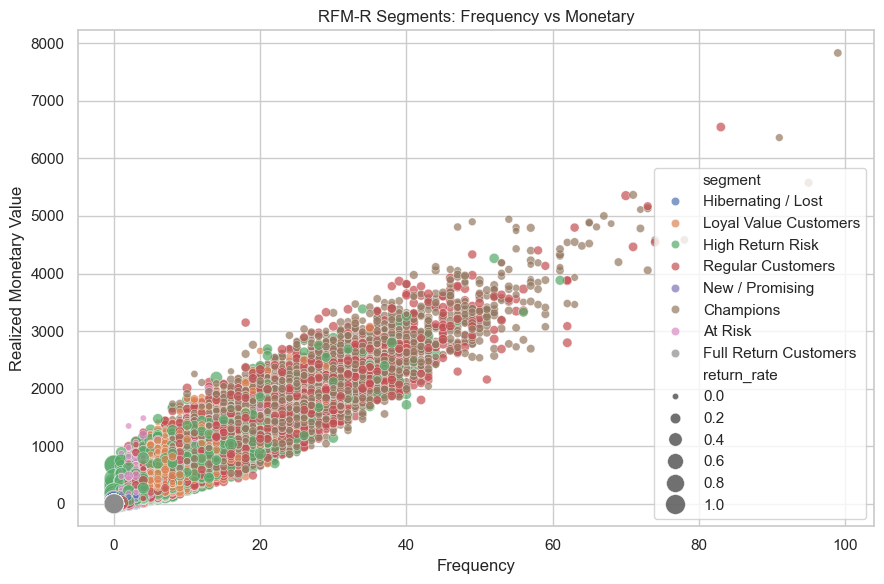

In [52]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfmr.reset_index(),
    x="frequency",
    y="monetary",
    hue="segment",
    size="return_rate",
    sizes=(20, 200),
    alpha=0.7
)
plt.title("RFM-R Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Realized Monetary Value")
plt.tight_layout()
plt.show()


The segment view shows that customer value is not one-dimensional. Champions occupy the strongest frequency and monetary area, while High Return Risk customers can still appear commercially meaningful before returns are considered. This is useful for campaign planning: high-spend customers should not automatically receive the same treatment if their return behavior is materially different.

### 4.10.6 Champion segment: frequency vs. monetary value

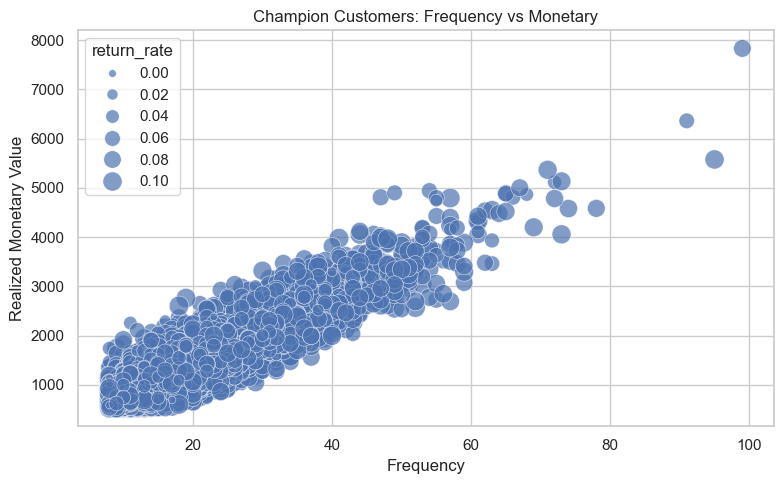

In [53]:
champions = rfmr[rfmr["segment"] == "Champions"].copy()

if len(champions) > 0:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=champions.reset_index(),
        x="frequency",
        y="monetary",
        size="return_rate",
        sizes=(30, 200),
        alpha=0.7
    )
    plt.title("Champion Customers: Frequency vs Monetary")
    plt.xlabel("Frequency")
    plt.ylabel("Realized Monetary Value")
    plt.tight_layout()
    plt.show()
else:
    print("No Champion segment found with current scoring thresholds.")


Champion customers show the strongest combination of repeat activity and realized monetary value. They are not simply one-time high spenders; the segment is defined by frequency, value, recency, and return behavior together. For a business team, this group is a natural starting point for loyalty analysis, recommendation testing, and retention monitoring.

### 4.10.7 Champion customers: recency distribution

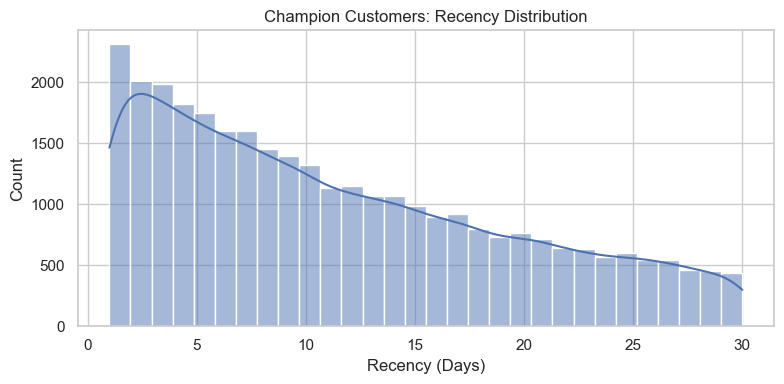

In [54]:
if len(champions) > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(champions["recency"], bins=30, kde=True)
    plt.title("Champion Customers: Recency Distribution")
    plt.xlabel("Recency (Days)")
    plt.tight_layout()
    plt.show()
else:
    print("No Champion segment found with current scoring thresholds.")


The Champion recency distribution is concentrated toward recent activity, which fits the segment definition. These customers have not only spent more and ordered more often; they are still active. That makes them more useful for near-term CRM work than customers who were valuable historically but have not returned recently.

### 4.10.8 Champion customers by acquisition channel

,order_lines,realized_revenue,return_rate
acquisition_channel,,,
direct_web,230090,"8,376,265.380",0.051
organic_search,172239,"6,190,259.260",0.058
paid_search,157592,"5,470,157.840",0.066
email_campaign,126848,"4,399,275.740",0.048
social_media,121553,"4,150,042.190",0.080
marketplace,81503,"2,911,752.440",0.072
affiliate_partner,76176,"2,651,103.940",0.068


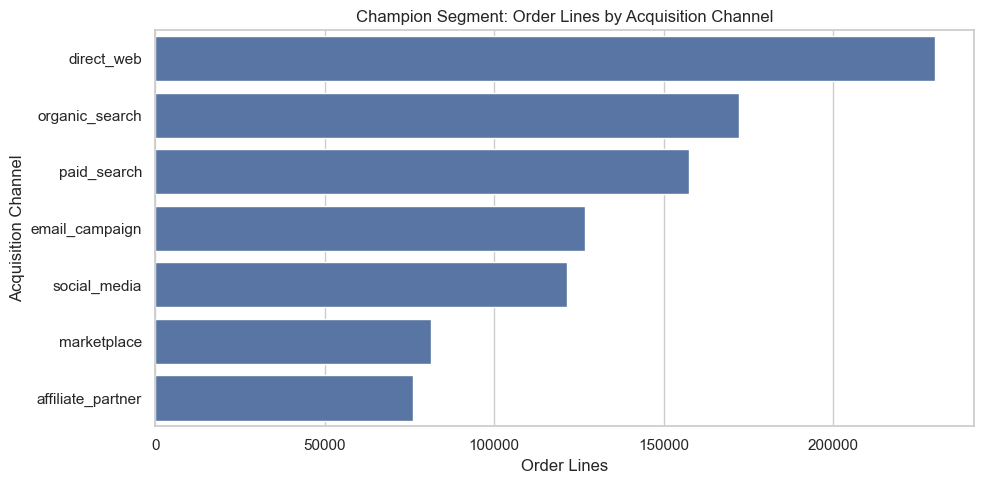

In [55]:
if len(champions) > 0:
    champion_ids = champions.index.tolist()

    champion_channel = (
        analysis_df[analysis_df[SCHEMA["customer_id"]].isin(champion_ids)]
        .groupby(SCHEMA["channel"])
        .agg(
            order_lines=(SCHEMA["order_line_id"], "count"),
            realized_revenue=(SCHEMA["realized_revenue"], "sum"),
            return_rate=(SCHEMA["return_flag"], "mean")
        )
        .sort_values("order_lines", ascending=False)
    )

    display(champion_channel)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=champion_channel.reset_index(), x="order_lines", y=SCHEMA["channel"])
    plt.title("Champion Segment: Order Lines by Acquisition Channel")
    plt.xlabel("Order Lines")
    plt.ylabel("Acquisition Channel")
    plt.tight_layout()
    plt.show()
else:
    print("No Champion segment found with current scoring thresholds.")


Champion customers are most strongly represented in **direct web**, followed by organic search and paid search. Owned and search-driven channels appear to contribute a large share of the highest-quality repeat customers. Email campaign also shows comparatively low return behavior among Champions, even though its volume is lower than the largest channels. This makes it a useful channel to review for loyalty, repeat-purchase, and recommendation experiments.

# 5. Export Curated Analysis Dataset

The curated analysis dataset is exported for downstream modules. It keeps the shared column names and reusable EDA features for return prediction, revenue prediction, churn, CLV, recommendation, and forecasting notebooks.


In [56]:
from pathlib import Path

export_dir = Path(".")
parquet_path = export_dir / "analysis_dataset_public.parquet"
csv_gz_path = export_dir / "analysis_dataset_public.csv.gz"

analysis_df_export = analysis_df.copy()

# Convert interval/category/object columns safely before export.
for col in analysis_df_export.columns:
    dtype_str = str(analysis_df_export[col].dtype)

    if dtype_str in ["category", "interval"] or "Interval" in dtype_str:
        analysis_df_export[col] = analysis_df_export[col].astype("string")
    elif dtype_str in ["object", "string"]:
        analysis_df_export[col] = analysis_df_export[col].astype("string")

# Try Parquet first; always save compressed CSV fallback.
try:
    analysis_df_export.to_parquet(parquet_path, index=False)
    print("Saved Parquet:", parquet_path)
except Exception as e:
    print("Parquet export skipped or failed.")
    print("Reason:", repr(e))

analysis_df_export.to_csv(csv_gz_path, index=False, compression="gzip")
print("Saved compressed CSV:", csv_gz_path)


Saved Parquet: analysis_dataset_public.parquet
Saved compressed CSV: analysis_dataset_public.csv.gz


**Export note:** The curated dataset has been saved in both Parquet and compressed CSV formats. Downstream notebooks can load either format depending on the local environment and available dependencies.

# 6. Final EDA Summary and Next Steps

## Key takeaways

- The dataset contains **4.26M order lines**, enough to support product, channel, customer, and time-based analysis.
- The overall return rate is **11.04%**, so returns have a clear effect on retained revenue.
- Realized revenue is right-skewed: most order lines are lower-to-mid value, with a smaller high-value tail.
- Product and channel performance should be judged using realized revenue and return behavior together, not sales volume alone.

## Data quality summary

- `transaction_line_id` is unique across all rows.
- No fully duplicated rows were found.
- Critical fields have no missing values.
- Return timestamp logic is consistent with the return flag.
- Missingness is limited mainly to expected event fields or non-critical categorical attribution fields.

## Revenue and return insights

- **Everyday Apparel** generates the highest total realized revenue, followed by **Home Comfort** and **Outdoor Living**.
- Everyday Apparel also has the highest product-family return rate at **20.2%**, making it both a major revenue driver and a major return-risk area.
- Monthly realized revenue rises strongly toward November and December, with return rates also increasing during the peak period.
- Higher price buckets and longer delivery delays are associated with higher return rates.

## Customer, product, and channel insights

- Direct web contributes the largest order volume, realized revenue, and customer count, while keeping return behavior relatively low.
- Email campaign has comparatively low return behavior, making it commercially attractive despite lower volume than direct web or organic search.
- Adaptive RFM-R scoring keeps identical values together, which is especially important for zero-return customers.
- RFM-R segmentation separates high-quality repeat customers from groups with weaker recency, lower retained value, or higher return exposure.
- **Champions are recent, frequent, high-value customers** with relatively healthy return behavior, making them a strong retention and loyalty group.
- High Return Risk and Full Return Customers need a different view from standard high-value customer targeting because returns can reduce retained value.

## Operational insights

- Delivery mode matters: express has the shortest average delivery delay and lower return rate than economy and pickup-point modes.
- Fulfillment partners show similar average delivery delays, so no single partner appears to dominate operational risk in this dataset.
- Delivery timing should be considered as a candidate feature for return prediction and customer experience analysis.

## Next modeling modules

This EDA provides the foundation for the later modules:

1. **Return Prediction** — identify order lines with elevated return risk.
2. **Revenue Prediction** — estimate order-line realized revenue.
3. **Customer Churn** — identify customers at risk of not returning.
4. **CLV Prediction** — estimate customer value using behavior and return-aware features.
5. **Recommendation Engine** — build product recommendation logic from customer-item behavior.
6. **Revenue Forecasting** — model monthly realized revenue and seasonality.